# Stack Overflow Survey EDA (2015-2025)

This notebook is meant to be a first step baseline to:
- focus on 2015-2025 only
- find the main structure of the survey data
- find data cleaning issues and patterns worth deeper analysis

## Plan

1. Inventory the files and the main analysis features
2. Group the raw columns into useful categories
3. Build one lightweight cross-year table for core analysis targets
4. Basic quality checks
5. Explore geography, demographics, experience, role mix, compensation, satisfaction, technology, and AI
6. Create a cleaning backlog

In [51]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive')

# Set display defaults for pandas, seaborn, and matplotlib
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

def find_root():
    here = Path.cwd()
    for path in [here, *here.parents]:
        if (path / 'data').exists():
            return path
    raise FileNotFoundError("Could not find project root")

ROOT = find_root()
DATA_DIR = ROOT / 'data'

print(ROOT)

/Users/aprilvin/Documents/6211 project/DSBA-6211-Stack-overflow-Survey-Analysis


## Yearly Info Columns

For some reason the people running a computer science website didn't think it'd be a good idea to standardize the questions they're asking and the format. So this horrific thing is how I manually went through chose the columns that matched specific question types. Please feel free to update it if there are columns I missed or ones that better fit the question.

In [52]:
YEAR_INFO = {
    2015: {
        'file': '2015 Stack Overflow Developer Survey Responses.csv',
        'header': 1,
        'response_id': None,
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': None,
        'student': None,
        'employment': 'Employment Status',
        'education': None,
        'org_size': None,
        'dev_type': 'Occupation',
        'industry': 'Industry',
        'remote': 'Remote Status',
        'years_code': 'Years IT / Programming Experience',
        'years_code_pro': None,
        'work_exp': None,
        'comp': 'Compensation: midpoint',
        'job_sat': 'Job Satisfaction',
        'career_sat': None,
        'language': None,
        'database': None,
        'platform': None,
        'ai_use': None,
        'ai_sent': None
    },
    2016: {
        'file': '2016 Stack Overflow Survey Responses.csv',
        'header': 0,
        'response_id': None,
        'country': 'country',
        'age': 'age_midpoint',
        'gender': 'gender',
        'main_branch': None,
        'student': None,
        'employment': 'employment_status',
        'education': 'education',
        'org_size': 'company_size_range',
        'dev_type': 'occupation',
        'industry': 'industry',
        'remote': 'remote',
        'years_code': 'experience_range',
        'years_code_pro': 'experience_range',
        'work_exp': None,
        'comp': 'salary_midpoint',
        'job_sat': None,
        'career_sat': None,
        'language': None,
        'database': None,
        'platform': None,
        'ai_use': None,
        'ai_sent': None
    },
    2017: {
        'file': 'survey_results_public2017.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': None,
        'gender': None,
        'main_branch': None,
        'student': None,
        'employment': 'EmploymentStatus',
        'education': 'FormalEducation',
        'org_size': 'CompanySize',
        'dev_type': 'DeveloperType',
        'industry': None,
        'remote': 'HomeRemote',
        'years_code': 'YearsProgram',
        'years_code_pro': 'YearsCodedJob',
        'work_exp': None,
        'comp': 'Salary',
        'job_sat': 'JobSatisfaction',
        'career_sat': 'CareerSatisfaction',
        'language': 'HaveWorkedLanguage',
        'database': 'HaveWorkedDatabase',
        'platform': 'HaveWorkedPlatform',
        'ai_use': None,
        'ai_sent': None
    },
    2018: {
        'file': 'survey_results_public2018.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': None,
        'student': 'Student',
        'employment': 'Employment',
        'education': 'FormalEducation',
        'org_size': 'CompanySize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCoding',
        'years_code_pro': 'YearsCodingProf',
        'work_exp': None,
        'comp': 'ConvertedSalary',
        'job_sat': 'JobSatisfaction',
        'career_sat': 'CareerSatisfaction',
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2019: {
        'file': 'survey_results_public2019.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': 'MainBranch',
        'student': 'Student',
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': 'WorkRemote',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'comp': 'ConvertedComp',
        'job_sat': 'JobSat',
        'career_sat': 'CareerSat',
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2020: {
        'file': 'survey_results_2020.csv',
        'header': 0,
        'response_id': 'Respondent',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'comp': 'ConvertedComp',
        'job_sat': 'JobSat',
        'career_sat': None,
        'language': 'LanguageWorkedWith',
        'database': 'DatabaseWorkedWith',
        'platform': 'PlatformWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2021: {
        'file': 'survey_results_2021.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': None,
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': None,
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2022: {
        'file': 'survey_results_2022.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': 'Gender',
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': None,
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': None,
        'ai_sent': None
    },
    2023: {
        'file': 'survey_results_2023.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'comp': 'ConvertedCompYearly',
        'job_sat': None,
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': None,
        'ai_sent': 'AISent'
    },
    2024: {
        'file': 'survey_results_2024.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': 'YearsCodePro',
        'work_exp': 'WorkExp',
        'comp': 'ConvertedCompYearly',
        'job_sat': 'JobSat',
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': 'AISelect',
        'ai_sent': 'AISent'
    },
    2025: {
        'file': 'survey_results_2025.csv',
        'header': 0,
        'response_id': 'ResponseId',
        'country': 'Country',
        'age': 'Age',
        'gender': None,
        'main_branch': 'MainBranch',
        'student': None,
        'employment': 'Employment',
        'education': 'EdLevel',
        'org_size': 'OrgSize',
        'dev_type': 'DevType',
        'industry': 'Industry',
        'remote': 'RemoteWork',
        'years_code': 'YearsCode',
        'years_code_pro': None,
        'work_exp': 'WorkExp',
        'comp': 'ConvertedCompYearly',
        'job_sat': 'JobSat',
        'career_sat': None,
        'language': 'LanguageHaveWorkedWith',
        'database': 'DatabaseHaveWorkedWith',
        'platform': 'PlatformHaveWorkedWith',
        'ai_use': 'AISelect',
        'ai_sent': 'AISent'
    }
}

YEARS = sorted(YEAR_INFO)
YEARS

print(ROOT)
print(DATA_DIR)
print(DATA_DIR / YEAR_INFO[2015]['file'])

path = DATA_DIR / YEAR_INFO[2015]['file']

display(pd.read_csv(path, header=0, nrows=2))
display(pd.read_csv(path, header=1, nrows=0).columns.tolist()[:20])


/Users/aprilvin/Documents/6211 project/DSBA-6211-Stack-overflow-Survey-Analysis
/Users/aprilvin/Documents/6211 project/DSBA-6211-Stack-overflow-Survey-Analysis/data
/Users/aprilvin/Documents/6211 project/DSBA-6211-Stack-overflow-Survey-Analysis/data/2015 Stack Overflow Developer Survey Responses.csv


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Select all that apply,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,...,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176,Unnamed: 177,Unnamed: 178,Select all that apply.4,Unnamed: 180,Unnamed: 181,Unnamed: 182,Unnamed: 183,Unnamed: 184,Unnamed: 185,Unnamed: 186,Unnamed: 187,Unnamed: 188,Unnamed: 189,Unnamed: 190,Select all that apply.5,Unnamed: 192,Unnamed: 193,Unnamed: 194,Unnamed: 195,Unnamed: 196,Unnamed: 197,Unnamed: 198,Unnamed: 199,Unnamed: 200,Unnamed: 201,Unnamed: 202,Unnamed: 203,Select all that apply.6,Unnamed: 205,Unnamed: 206,Unnamed: 207,Unnamed: 208,Unnamed: 209,Unnamed: 210,Unnamed: 211,Unnamed: 212,Unnamed: 213,Select all that apply.7,Unnamed: 215,Unnamed: 216,Unnamed: 217,Unnamed: 218,Unnamed: 219,Unnamed: 220,Unnamed: 221
0,Country,Age,Gender,Tabs or Spaces,Years IT / Programming Experience,Occupation,Desktop Operating System,Desktop Operating System: write-in,Current Lang & Tech: Android,Current Lang & Tech: Arduino,Current Lang & Tech: AngularJS,Current Lang & Tech: C,Current Lang & Tech: C++,Current Lang & Tech: C++11,Current Lang & Tech: C#,Current Lang & Tech: Cassandra,Current Lang & Tech: CoffeeScript,Current Lang & Tech: Cordova,Current Lang & Tech: Clojure,Current Lang & Tech: Cloud,Current Lang & Tech: Dart,Current Lang & Tech: F#,Current Lang & Tech: Go,Current Lang & Tech: Hadoop,Current Lang & Tech: Haskell,Current Lang & Tech: iOS,Current Lang & Tech: Java,Current Lang & Tech: JavaScript,Current Lang & Tech: LAMP,Current Lang & Tech: Matlab,Current Lang & Tech: MongoDB,Current Lang & Tech: Node.js,Current Lang & Tech: Objective-C,Current Lang & Tech: Perl,Current Lang & Tech: PHP,Current Lang & Tech: Python,Current Lang & Tech: R,Current Lang & Tech: Redis,Current Lang & Tech: Ruby,Current Lang & Tech: Rust,Current Lang & Tech: Salesforce,Current Lang & Tech: Scala,Current Lang & Tech: Sharepoint,Current Lang & Tech: Spark,Current Lang & Tech: SQL,Current Lang & Tech: SQL Server,Current Lang & Tech: Swift,Current Lang & Tech: Visual Basic,Current Lang & Tech: Windows Phone,Current Lang & Tech: Wordpress,...,How can companies improve interview process: R...,How can companies improve interview process: I...,How can companies improve interview process: I...,How can companies improve interview process: G...,How can companies improve interview process: S...,How can companies improve interview process: F...,How can companies improve interview process: B...,Why try Stack Overflow Careers: No spam,Why try Stack Overflow Careers: Jobs site for ...,Why try Stack Overflow Careers: Selection of r...,Why try Stack Overflow Careers: Showcase Stack...,Why try Stack Overflow Careers: Jobs are on St...,Why try Stack Overflow Careers: Other,How many caffeinated beverages per day?,How many hours programming as hobby per week?,How frequently land on or read Stack Overflow,Preferred text editor,Preferred text editor: write-in,Prefered IDE theme,Source control used: Git,Source control used: Mercurial,Source control used: SVN,Source control used: CVS,Source control used: Perforce,Source control used: TFS,Source control used: DCVS,Source control used: Bitkeeper,Source control used: Legacy / Custom,Source control used: I don't use source control,Source control used: write-in,Prefered Source Control,Prefered Source Control: write-in,Why use Stack Overflow: Help for job,Why use Stack Overflow: To give help,Why use Stack Overflow: Can't do job without it,Why use Stack Overflow: Maint

['Country',
 'Age',
 'Gender',
 'Tabs or Spaces',
 'Years IT / Programming Experience',
 'Occupation',
 'Desktop Operating System',
 'Desktop Operating System: write-in',
 'Current Lang & Tech: Android',
 'Current Lang & Tech: Arduino',
 'Current Lang & Tech: AngularJS',
 'Current Lang & Tech: C',
 'Current Lang & Tech: C++',
 'Current Lang & Tech: C++11',
 'Current Lang & Tech: C#',
 'Current Lang & Tech: Cassandra',
 'Current Lang & Tech: CoffeeScript',
 'Current Lang & Tech: Cordova',
 'Current Lang & Tech: Clojure',
 'Current Lang & Tech: Cloud']

,survey_year,file_name,rows,columns
0,2015,2015 Stack Overflow Developer Survey Responses...,26086,222
1,2016,2016 Stack Overflow Survey Responses.csv,56030,66
2,2017,survey_results_public2017.csv,51392,154
3,2018,survey_results_public2018.csv,98855,129
4,2019,survey_results_public2019.csv,88883,85
5,2020,survey_results_2020.csv,64461,61
6,2021,survey_results_2021.csv,83439,48
7,2022,survey_results_2022.csv,73268,79
8,2023,survey_results_2023.csv,89184,84
9,2024,survey_results_2024.csv,65437,114


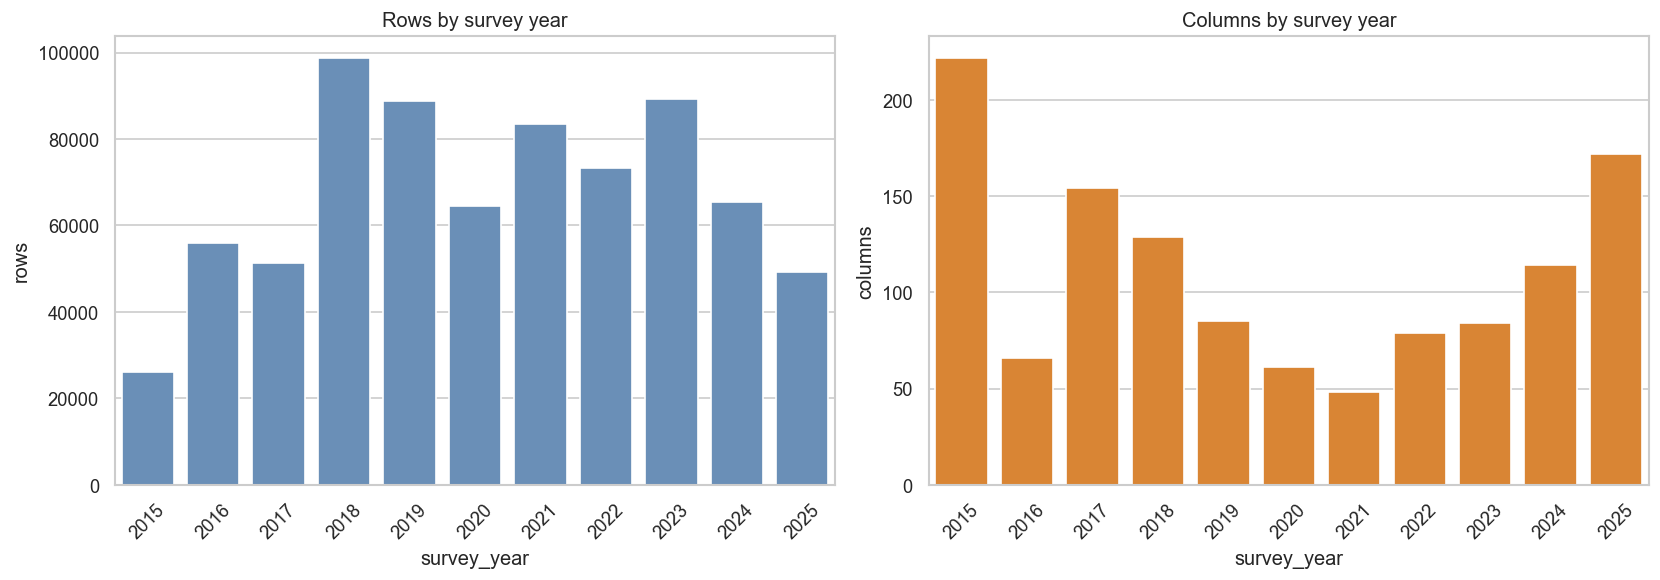

Potential analysis windows
- 2015-2018: transition years
- 2019-2022: strongest general modeling window
- 2023-2025: AI-era window


In [53]:
# Just want to get a count of how many columns and rows exist across each year

inventory_rows = []
for year in YEARS:
    info = YEAR_INFO[year]
    path = DATA_DIR / info['file']

    frame = pd.read_csv(path, header=info['header'], usecols=[0])
    header = pd.read_csv(path, header=info['header'], nrows=0)
    inventory_rows.append({
        'survey_year': year,
        'file_name': info['file'],
        'rows': len(frame),
        'columns': len(header.columns)
    })


inventory = pd.DataFrame(inventory_rows)
display(inventory)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=inventory, x='survey_year', y='rows', color='#5D8EC4', ax=axes[0])
axes[0].set_title("Rows by survey year")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=inventory, x='survey_year', y='columns', color='#F58518', ax=axes[1])
axes[1].set_title("Columns by survey year")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Potential analysis windows")
print("- 2015-2018: transition years")
print("- 2019-2022: strongest general modeling window")
print("- 2023-2025: AI-era window")

## Raw Column Categories

Before loading specific analysis tables, it'd be a good idea to group questions into category types. The code below uses keywords present across the years to group questions into categories:
demographics, education, work context, experience, compensation, satisfaction, technology, AI, and Stack Overflow behavior.


category,ai,comp_sat,education,experience,identity,other,stack_overflow,technology,work
survey_year,,,,,,,,,
2015,0,21,11,1,3,59,30,89,8
2016,0,4,1,2,4,44,1,5,5
2017,0,10,6,3,2,110,1,14,8
2018,4,6,4,2,4,95,2,8,4
2019,0,5,2,3,8,36,14,12,5
2020,0,4,2,3,7,23,7,11,4
2021,0,3,2,3,8,7,7,15,3
2022,0,3,4,3,7,30,7,21,4
2023,13,2,4,3,3,21,7,26,5


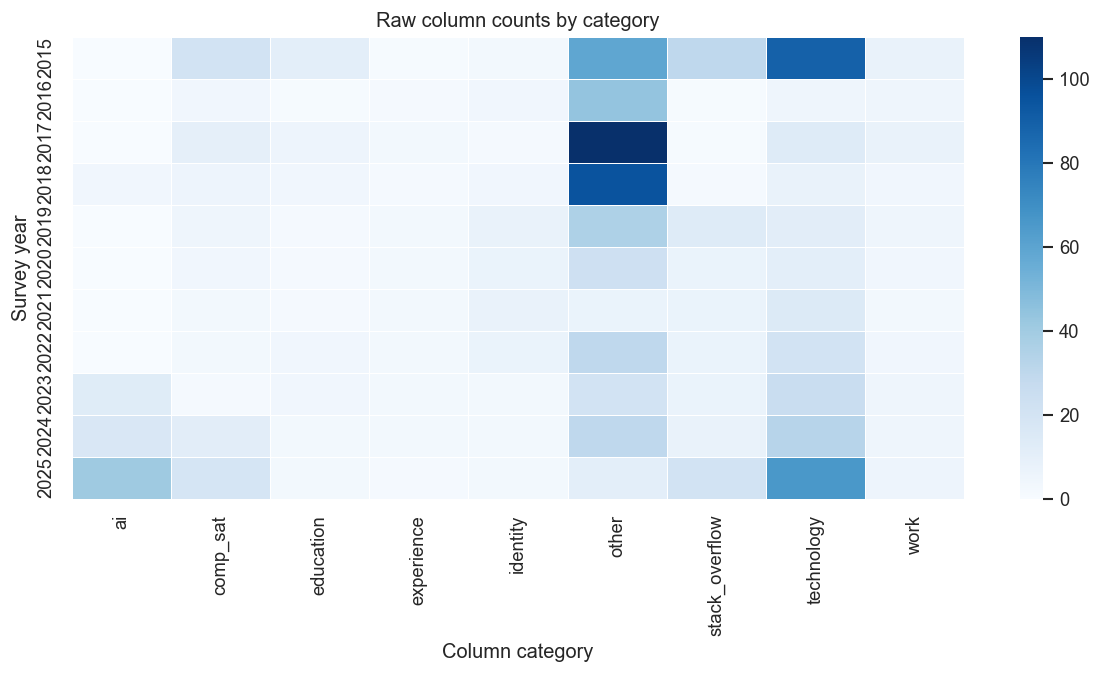

,survey_year,category,sample_columns
0,2015,comp_sat,"Compensation, Compensation: midpoint, Most imp..."
1,2015,education,"Training & Education: No formal training, Trai..."
2,2015,experience,Years IT / Programming Experience
3,2015,identity,"Country, Age, Gender"
4,2015,other,"Tabs or Spaces, Desktop Operating System, Desk..."
5,2015,stack_overflow,Perception of contact form: Stack Overflow Car...
6,2015,technology,"Current Lang & Tech: Android, Current Lang & T..."
7,2015,work,"Occupation, Employment Status, Industry, Remot..."
8,2016,comp_sat,"salary_range, salary_midpoint, company_size_ra..."
9,2016,education,education


In [54]:
headers = {}
for year in YEARS:
    info = YEAR_INFO[year]
    path = DATA_DIR / info["file"]
    cols = pd.read_csv(path, header=info["header"], nrows=0).columns.tolist()
    headers[year] = cols


# There's probably a much better way to do this, but these are potential groupings I found. Feel free to add things I missed
def column_category(column):
    c = column.lower()

    if any(x in c for x in [
        "language",
        "database",
        "platform",
        "webframe",
        "framework",
        "misctech",
        "devenv",
        "opsys",
        "haveworked",
        "wanttowork",
        "tech"
    ]):
        return "technology"

    if (
        c.startswith("ai")
        or c.startswith("soai")
        or "learncodeai" in c
        or "aidev" in c
        or "aisearch" in c
        or "aimodel" in c
        or "aiagent" in c
    ):
        return "ai"

    if (c in {
        "country",
        "age",
        "gender",
        "mainbranch",
        "student",
        "ethnicity",
        "sexuality",
        "trans",
        "uk_country"
    }
        or c.startswith("country")
        or c in {"age_range", "age_midpoint"}
    ):
        return "identity"

    if any(x in c for x in [
        "edlevel",
        "formaleducation",
        "undergradmajor",
        "learncode",
        "education",
        "training & education",
    ]):
        return "education"

    if any(x in c for x in [
        "employment",
        "orgsize",
        "companysize",
        "industry",
        "remote",
        "devtype",
        "occupation",
        "jobseek",
        "lastnewjob",
    ]):
        return "work"

    if any(x in c for x in [
        "yearscode",
        "yearscoding",
        "yearsprogram",
        "yearscodedjob",
        "workexp",
        "experience",
        "age1stcode",
    ]):
        return "experience"

    if any(x in c for x in [
        "comp",
        "salary",
        "jobsat",
        "careersat",
        "jobsatisfaction",
        "careersatisfaction",
        "jobsatpoints",
    ]):
        return "comp_sat"

    if (
        c.startswith("so")
        or "stack overflow" in c
        or "survey" in c
        or "newsosites" in c
    ):
        return "stack_overflow"

    return "other"


# Creates a DataFrame with counts of the number of columns belonging to each grouping per year
header_rows = []
for year, cols in headers.items():
    for column in cols:
        header_rows.append({
            "survey_year": year,
            "column": column,
            "category": column_category(str(column)),
        })

header_long = pd.DataFrame(header_rows)
category_counts = header_long.pivot_table(
    index="survey_year",
    columns="category",
    values="column",
    aggfunc="count",
    fill_value=0,
)
display(category_counts)

# Visual representation of the above DataFrame
plt.figure(figsize=(12, 5))
sns.heatmap(category_counts, cmap="Blues", linewidths=0.5)
plt.title("Raw column counts by category")
plt.xlabel("Column category")
plt.ylabel("Survey year")
plt.show()

# Sample of some of the columns that exist in the created groups per year
category_examples = (
    header_long.groupby(["survey_year", "category"])["column"]
    .apply(lambda s: ", ".join(s.head(5)))
    .reset_index(name="sample_columns")
)
display(category_examples)

## Core Analysis Map

Visual mapping of core fields for analysis best used for later cleaning that exist across the years.

,file,header,response_id,country,age,gender,main_branch,student,employment,education,org_size,dev_type,industry,remote,years_code,years_code_pro,work_exp,comp,job_sat,career_sat,language,database,platform,ai_use,ai_sent
2015,2015 Stack Overflow Developer Survey Responses...,1,None,Country,Age,Gender,None,None,Employment Status,None,None,Occupation,Industry,Remote Status,Years IT / Programming Experience,None,None,Compensation: midpoint,Job Satisfaction,None,None,None,None,None,None
2016,2016 Stack Overflow Survey Responses.csv,0,None,country,age_midpoint,gender,None,None,employment_status,education,company_size_range,occupation,industry,remote,experience_range,experience_range,None,salary_midpoint,None,None,None,None,None,None,None
2017,survey_results_public2017.csv,0,Respondent,Country,None,None,None,None,EmploymentStatus,FormalEducation,CompanySize,DeveloperType,None,HomeRemote,YearsProgram,YearsCodedJob,None,Salary,JobSatisfaction,CareerSatisfaction,HaveWorkedLanguage,HaveWorkedDatabase,HaveWorkedPlatform,None,None
2018,survey_results_public2018.csv,0,Respondent,Country,Age,Gender,None,Student,Employment,FormalEducation,CompanySize,DevType,None,None,YearsCoding,YearsCodingProf,None,ConvertedSalary,JobSatisfaction,CareerSatisfaction,LanguageWorkedWith,DatabaseWorkedWith,PlatformWorkedWith,None,None
2019,survey_results_public2019.csv,0,Respondent,Country,Age,Gender,MainBranch,Student,Employment,EdLevel,OrgSize,DevType,None,WorkRemote,YearsCode,YearsCodePro,None,ConvertedComp,JobSat,CareerSat,LanguageWorkedWith,DatabaseWorkedWith,PlatformWorkedWith,None,None
2020,survey_results_2020.csv,0,Respondent,Country,Age,Gender,MainBranch,None,Employment,EdLevel,OrgSize,DevType,None,None,YearsCode,YearsCodePro,None,ConvertedComp,JobSat,None,LanguageWorkedWith,DatabaseWorkedWith,PlatformWorkedWith,None,None
2021,survey_results_2021.csv,0,ResponseId,Country,Age,Gender,MainBranch,None,Employment,EdLevel,OrgSize,DevType,None,None,YearsCode,YearsCodePro,None,ConvertedCompYearly,None,None,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,None,None
2022,survey_results_2022.csv,0,ResponseId,Country,Age,Gender,MainBranch,None,Employment,EdLevel,OrgSize,DevType,None,RemoteWork,YearsCode,YearsCodePro,WorkExp,ConvertedCompYearly,None,None,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,None,None
2023,survey_results_2023.csv,0,ResponseId,Country,Age,None,MainBranch,None,Employment,EdLevel,OrgSize,DevType,Industry,RemoteWork,YearsCode,YearsCodePro,WorkExp,ConvertedCompYearly,None,None,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,None,AISent
2024,survey_results_2024.csv,0,ResponseId,Country,Age,None,MainBranch,None,Employment,EdLevel,OrgSize,DevType,Industry,RemoteWork,YearsCode,YearsCodePro,WorkExp,ConvertedCompYearly,JobSat,None,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,AISelect,AISent


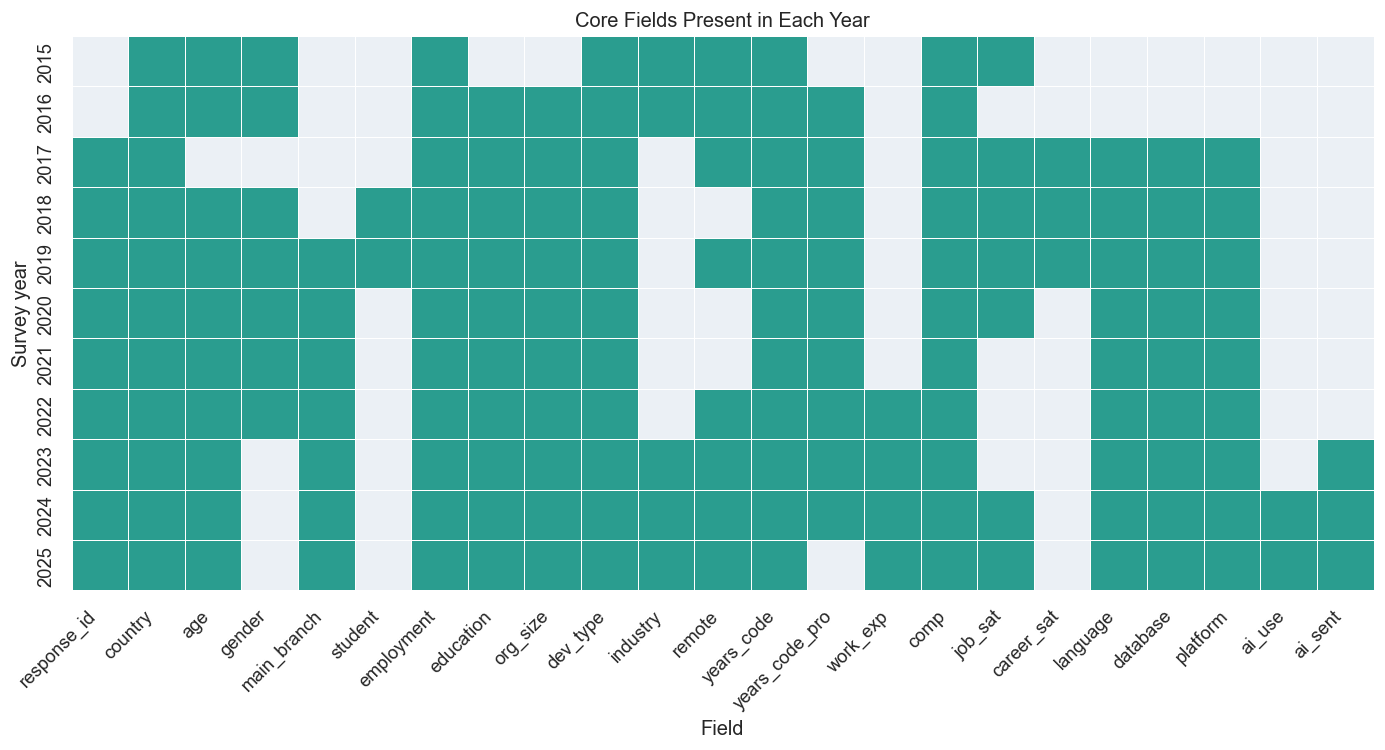

In [55]:
field_map = pd.DataFrame(YEAR_INFO).T
display(field_map)

presence = field_map.drop(columns=['file', 'header']).notna().astype(int)
plt.figure(figsize=(14, 6))
sns.heatmap(
    presence,
    cmap=sns.color_palette(['#EBF0F5', '#2A9D8F'], as_cmap=True),
    cbar=False,
    linewidths=0.5
)
plt.title("Core Fields Present in Each Year")
plt.xlabel('Field')
plt.ylabel('Survey year')
plt.xticks(rotation=45, ha='right')
plt.show()

## Build A Lightweight Cross-Year Table

I modify this a little later in the cleaning notebook, but this is a quick and grouping of all the years into a standardized format.

In [56]:
# Many values are ranges with different formatting; this should handle all formats and convert it to a single average value
def parse_midpoint(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).strip()
    lower = text.lower()
    numbers = [float(x) for x in re.findall(r"\d+(?:\.\d+)?", text.replace(',', ''))]

    if not numbers:
        return np.nan
    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    if 'under' in lower or text.startswith('<'):
        return max(numbers[0] - 1, 0)
    return numbers[0]


# Helper to quickly pull in the desired columns for a given year
def read_year(year, columns):
    info = YEAR_INFO[year]
    path = DATA_DIR / info['file']
    return pd.read_csv(
        path,
        header=info['header'],
        usecols=columns,
        low_memory=False
    )


# Takes all the years and makes a unified DataFrame with a standardized format
def load_year(year):
    info = YEAR_INFO[year]
    selected = [value for key, value in info.items() if key not in ['file', 'header'] and value is not None]
    df = read_year(year, selected)

    out = pd.DataFrame(index=df.index)
    out['row_id'] = year * 1_000_000 + np.arange(len(df))
    out['survey_year'] = year

    for field in [
        'response_id',
        'country',
        'age',
        'gender',
        'main_branch',
        'student',
        'employment',
        'education',
        'org_size',
        'dev_type',
        'industry',
        'remote',
        'years_code',
        'years_code_pro',
        'work_exp',
        'comp',
        'job_sat',
        'career_sat',
        'language',
        'database',
        'platform',
        'ai_use',
        'ai_sent'
    ]:
        raw_col = info[field]
        out[field] = df[raw_col] if raw_col is not None else pd.NA

    out['age_num'] = out['age'].map(parse_midpoint)
    out['years_code_num'] = out['years_code'].map(parse_midpoint)
    out['years_code_pro_num'] = out['years_code_pro'].map(parse_midpoint)
    out['work_exp_num'] = out['work_exp'].map(parse_midpoint)
    out['comp_usd'] = out['comp'].map(parse_midpoint)
    out['job_sat_num'] = pd.to_numeric(out['job_sat'], errors='coerce')

    return out

# Random sample of the unified table
core = pd.concat([load_year(year) for year in YEARS], ignore_index=True)
print(core.shape)
display(core.sample(8, random_state=42))

(746226, 31)


,row_id,survey_year,response_id,country,age,gender,main_branch,student,employment,education,org_size,dev_type,industry,remote,years_code,years_code_pro,work_exp,comp,job_sat,career_sat,language,database,platform,ai_use,ai_sent,age_num,years_code_num,years_code_pro_num,work_exp_num,comp_usd,job_sat_num
660422,2024028824,2024,28825,Thailand,25-34 years old,NaN,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10 to 19 employees,"Developer, full-stack",NaN,In-person,8,1,NaN,NaN,NaN,NaN,C#;HTML/CSS;JavaScript;SQL,MariaDB;MongoDB;MySQL,NaN,Yes,Favorable,29.5,8.0,1.0,NaN,NaN,NaN
115194,2017033078,2017,33079,New Zealand,NaN,NaN,NaN,NaN,"Not employed, and not looking for work",Secondary school,NaN,NaN,NaN,NaN,2 to 3 years,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN
462718,2021077011,2021,77012,Denmark,35-44 years old,Man,I am a developer by profession,NaN,Employed full-time,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",20 to 99 employees,"Developer, desktop or enterprise applications;...",NaN,NaN,30,20,NaN,118104.0,NaN,NaN,Clojure;Haskell;Kotlin,DynamoDB;PostgreSQL;SQLite,AWS;DigitalOcean,NaN,NaN,39.5,30.0,20.0,NaN,118104.0,NaN
683102,2024051504,2024,51505,United States of America,25-34 years old,NaN,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","5,000 to 9,999 employees","Developer, back-end",Software Development,"Hybrid (some remote, some in-person)",14,6,6.0,NaN,7.0,NaN,Java,MySQL,Amazon Web Services (AWS),"No, and I don't plan to",NaN,29.5,14.0,6.0,6.0,NaN,7.0
116754,2017034638,2017,34639,United States,NaN,NaN,NaN,NaN,Employed full-time,Bachelor's degree,100 to 499 employees,Web developer,NaN,All or almost all the time (I'm full-time remote),14 to 15 years,8 to 9 years,NaN,NaN,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,14.5,8.5,NaN,NaN,6.0
533507,2022064361,2022,64362,United States of America,55-64 years old,Man,I am a developer by profession,NaN,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",100 to 499 employees,"Developer, back-end;Other (please specify):",NaN,"Hybrid (some remote, some in-person)",32,28,28.0,116000.0,NaN,NaN,C#;PowerShell;SQL,Microsoft SQL Server,Microsoft Azure,NaN,NaN,59.5,32.0,28.0,28.0,116000.0,NaN
298513,2019066150,2019,66571,United States,21.0,Man,I am a developer by profession,No,Employed full-time,"Bachelor’s degree (BA, BS, B.Eng., etc.)",100 to 499 employees,"Developer, desktop or enterprise applications;...",NaN,Less than once per month / Never,6,1,NaN,51000.0,Very satisfied,Very satisfied,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript,NaN,Windows,NaN,NaN,21.0,6.0,1.0,NaN,51000.0,NaN
199246,2018065738,2018,93313,Germany,NaN,NaN,NaN,"Yes, full-time",Employed full-time,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",20 to 99 employees,Back-end developer;Desktop or enterprise appli...,NaN,NaN,24-26 years,15-17 years,NaN,NaN,Extremely dissatisfied,Moderately dissatisfied,C;C++;C#;JavaScript;Python;SQL;HTML;CSS;Bash/S...,MongoDB;SQL Server,Android;Linux;Windows Desktop or Server,NaN,NaN,NaN,25.0,16.0,NaN,NaN,NaN


# Check programming languages popularity over time

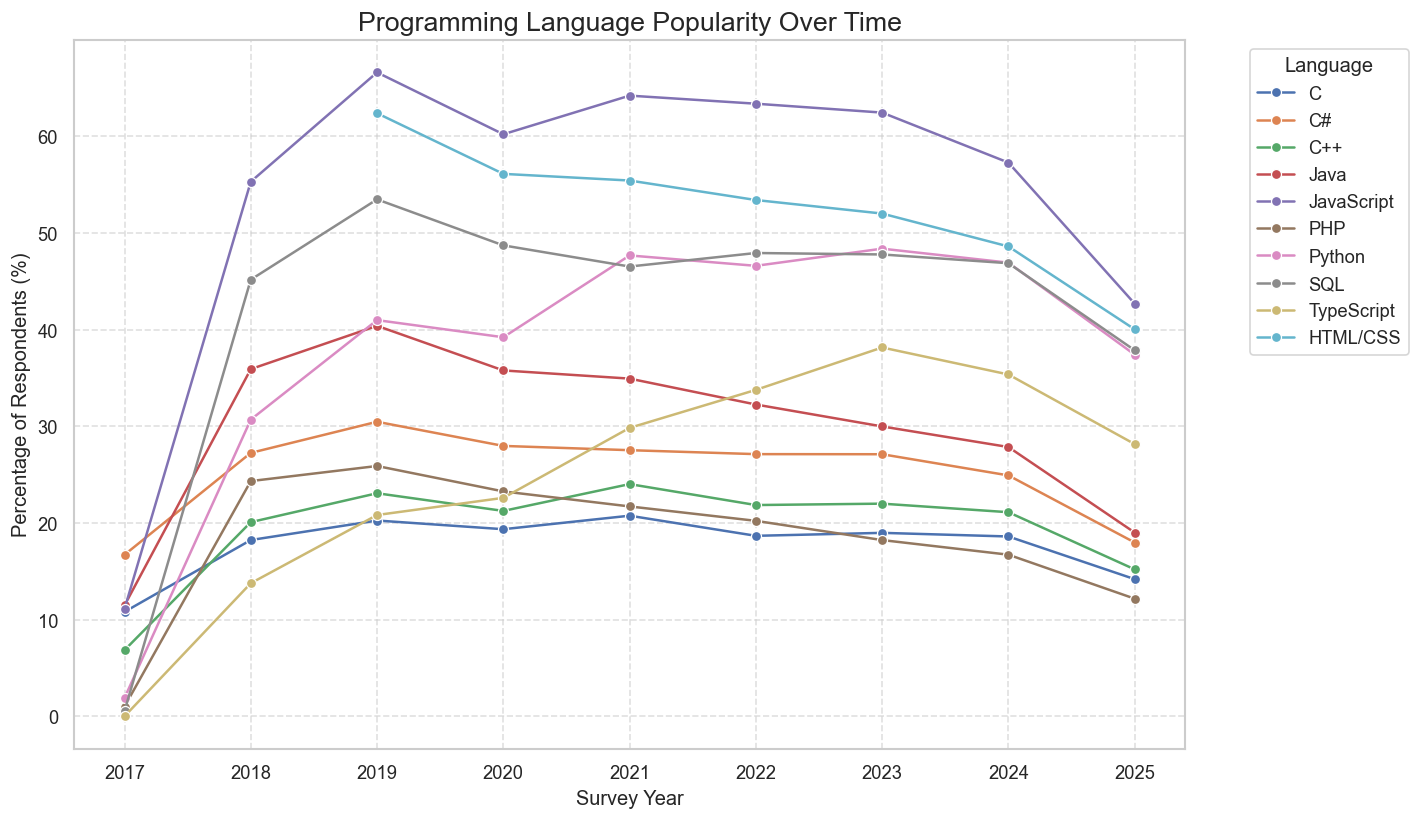

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Handle the multi-value 'language' column
# Split the strings into lists and explode them into individual rows
df_lang = core.assign(language=core['language'].str.split(';')).explode('language')

# Calculate Popularity (Percentage of respondents per year)
# We group by year and language, then divide by the total number of unique respondents that year
yearly_totals = core.groupby('survey_year')['response_id'].nunique()
lang_counts = df_lang.groupby(['survey_year', 'language']).size().reset_index(name='count')

# Merge to get total respondents per year for percentage calculation
lang_trends = lang_counts.merge(yearly_totals, on='survey_year')
lang_trends['percentage'] = (lang_trends['count'] / lang_trends['response_id']) * 100

# Filter for Top 10 Languages (to keep the chart clean)
top_langs = lang_trends.groupby('language')['count'].sum().nlargest(10).index
lang_trends_filtered = lang_trends[lang_trends['language'].isin(top_langs)]

# Visualization
plt.figure(figsize=(12, 7))
sns.lineplot(data=lang_trends_filtered, x='survey_year', y='percentage', hue='language', marker='o')

plt.title('Programming Language Popularity Over Time', fontsize=16)
plt.ylabel('Percentage of Respondents (%)')
plt.xlabel('Survey Year')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

,rows,employed_share,professional_share,comp_sample_share,sat_sample_share
survey_year,,,,,
2015,26086,0.666,0.652,0.517,0.620
2016,56030,0.748,0.732,0.653,0.000
2017,51392,0.867,0.867,0.245,0.831
2018,98855,0.861,0.781,0.420,0.774
2019,88883,0.871,0.760,0.551,0.820
2020,64461,0.825,0.752,0.479,0.701
2021,83439,0.768,0.712,0.503,0.000
2022,73268,0.796,0.748,0.463,0.000
2023,89184,0.819,0.775,0.490,0.000


,response_id,country,age_num,gender,main_branch,employment,education,org_size,dev_type,remote,years_code_num,years_code_pro_num,work_exp_num,comp_usd,job_sat,language,database,platform,ai_use,ai_sent
survey_year,,,,,,,,,,,,,,,,,,,,
2015,0.0,96.9,97.7,98.7,0.0,81.7,0.0,0.0,79.9,61.9,95.2,0.0,0.0,57.0,62.0,0.0,0.0,0.0,0.0,0.0
2016,0.0,99.1,98.8,99.2,0.0,88.5,80.2,71.3,88.4,71.6,88.4,88.4,0.0,74.5,0.0,0.0,0.0,0.0,0.0,0.0
2017,100.0,100.0,0.0,0.0,0.0,100.0,100.0,75.7,70.3,85.6,96.6,73.7,0.0,25.1,78.6,71.3,57.3,56.7,0.0,0.0
2018,100.0,99.6,65.3,65.2,0.0,96.4,95.8,72.4,93.2,0.0,94.9,78.8,0.0,48.3,70.1,79.2,67.0,66.8,0.0,0.0
2019,100.0,99.9,89.1,96.1,99.4,98.1,97.2,80.8,91.5,79.1,98.9,83.6,0.0,62.8,79.9,98.5,85.5,90.8,0.0,0.0
2020,100.0,99.4,70.5,78.4,99.5,99.1,89.1,68.8,76.6,0.0,89.5,71.9,0.0,53.9,70.1,89.0,76.8,83.5,0.0,0.0
2021,100.0,100.0,98.1,98.6,100.0,99.9,99.6,72.8,79.7,0.0,97.8,73.4,0.0,56.1,0.0,98.7,83.3,62.5,0.0,0.0
2022,100.0,98.0,96.1,96.7,100.0,97.9,97.7,69.7,83.7,80.5,97.4,70.7,50.2,52.0,0.0,96.9,82.1,68.1,0.0,0.0
2023,100.0,98.6,99.5,0.0,100.0,98.6,98.6,72.9,86.2,82.8,98.0,74.2,48.9,53.8,0.0,97.7,82.3,71.3,0.0,69.0


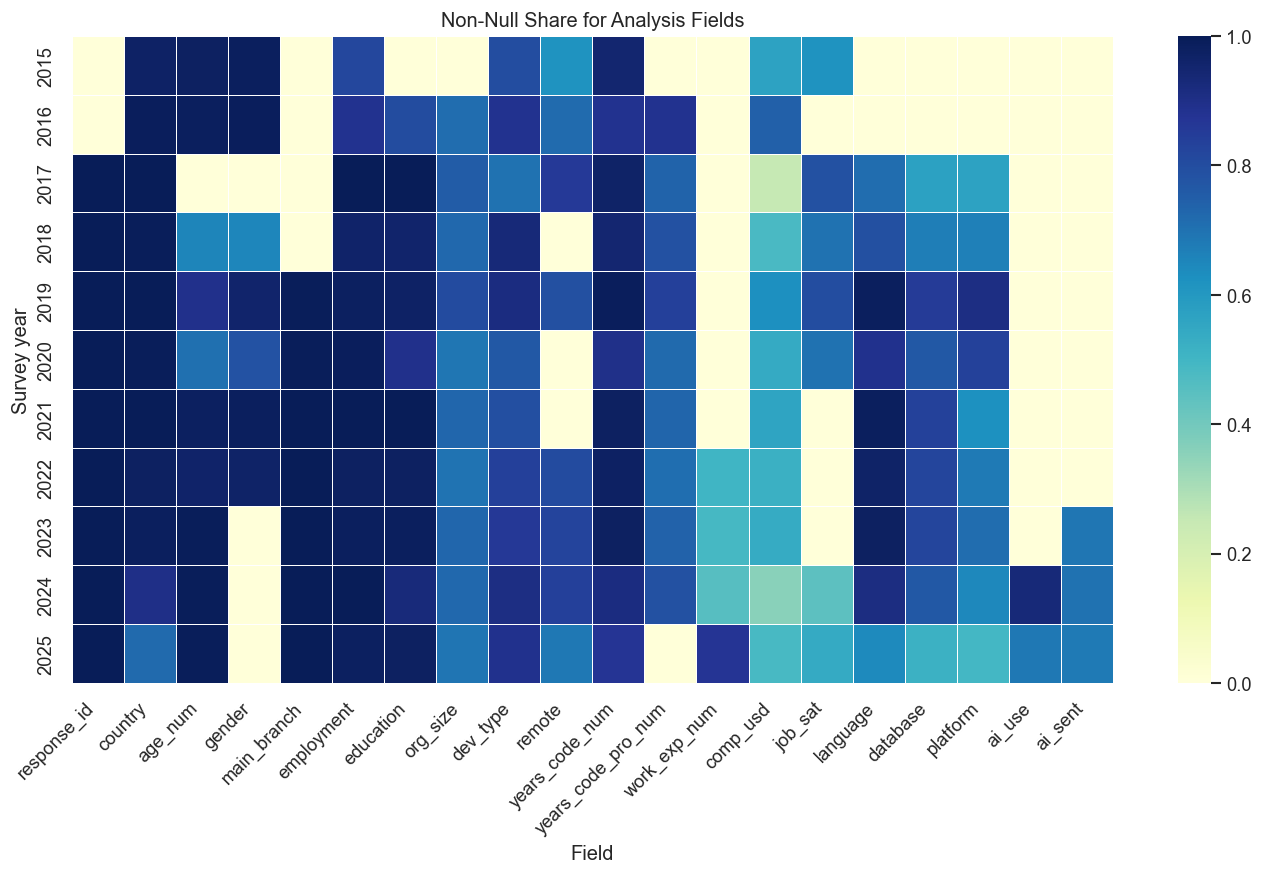

In [58]:
# Don't want to type this for every Series with text fields I encounter
def lower_text(series):
    return series.fillna('').astype(str).str.lower()

employment_text = lower_text(core['employment'])
branch_text = lower_text(core['main_branch'])
dev_text = lower_text(core['dev_type'])

# All potential values noting the person is employed
core['is_employed'] = (
    employment_text.str.contains('employed')
    | employment_text.str.contains('contractor')
    | employment_text.str.contains('freelance')
    | employment_text.str.contains('self-employed')
) & ~employment_text.str.contains('not employed')

# All potential values noting the person does CS, DS, or dev by profession or is employed
core['is_professional'] = np.where(
    branch_text.ne(''),
    branch_text.str.contains("developer by profession"),
    core['is_employed'] & ~dev_text.str.contains('student')
)

# Realistic values for whether a person is compensated and has a reported satisfaction
core['is_comp_sample'] = core['is_professional'] & core['comp_usd'].between(1000, 1_000_000)
core['is_sat_sample'] = core['job_sat'].notna() | core['career_sat'].notna()

# Summary of what percent of responses are not null for the created cohorts per year
cohort_summary = core.groupby('survey_year').agg(
    rows=('row_id', 'size'),
    employed_share=('is_employed', 'mean'),
    professional_share=('is_professional', 'mean'),
    comp_sample_share=('is_comp_sample', 'mean'),
    sat_sample_share=('is_sat_sample', 'mean')
)
display(cohort_summary.round(3))

# Overall percent of not null values for some of the main features we want to use
coverage = core.groupby('survey_year')[[
    'response_id',
    'country',
    'age_num',
    'gender',
    'main_branch',
    'employment',
    'education',
    'org_size',
    'dev_type',
    'remote',
    'years_code_num',
    'years_code_pro_num',
    'work_exp_num',
    'comp_usd',
    'job_sat',
    'language',
    'database',
    'platform',
    'ai_use',
    'ai_sent'
]].apply(lambda x: x.notna().mean())
display((coverage * 100).round(1))

# Visual representation of the DataFrame directly above
plt.figure(figsize=(14, 7))
sns.heatmap(coverage, cmap='YlGnBu', linewidths=0.5)
plt.title("Non-Null Share for Analysis Fields")
plt.xticks(rotation=45, ha='right')
plt.xlabel('Field')
plt.ylabel('Survey year')
plt.show()

## Quality Checks

These are simple baseline checks to quickly see where things look missing, duplicated, or suspicious before modeling.

In [59]:
quality_rows = []
for year, frame in core.groupby('survey_year'):
    id_series = frame['response_id'].dropna()
    quality_rows.append({
        'survey_year': year,
        'duplicate_ids': id_series.duplicated().sum(),
        'special_country_rows': frame['country'].isin(['Nomadic', 'Other Country (Not Listed Above)', 'I prefer not to say']).sum(),
        'age_out_of_range': ((frame['age_num'] < 10) | (frame['age_num'] > 90)).sum(),
        'years_code_gt_50': (frame['years_code_num'] > 50).sum(),
        'years_code_pro_gt_years_code': (
            (frame['years_code_pro_num'] > frame['years_code_num'])
            & frame['years_code_num'].notna()
            & frame['years_code_pro_num'].notna()
        ).sum(),
        'work_exp_gt_50': (frame['work_exp_num'] > 50).sum(),
        'comp_outside_range': (frame['comp_usd'].notna() & ~frame['comp_usd'].between(0, 1_000_000)).sum()
    })

quality = pd.DataFrame(quality_rows)
display(quality)

,survey_year,duplicate_ids,special_country_rows,age_out_of_range,years_code_gt_50,years_code_pro_gt_years_code,work_exp_gt_50,comp_outside_range
0,2015,0,0,0,0,0,0,0
1,2016,0,0,0,0,0,0,0
2,2017,0,140,0,0,457,0,0
3,2018,0,84,0,0,629,0,394
4,2019,0,136,64,0,969,0,1118
5,2020,0,31,26,0,476,0,398
6,2021,0,54,0,0,647,0,607
7,2022,0,37,0,0,536,0,865
8,2023,0,61,0,0,682,0,60
9,2024,0,43,0,0,498,0,41


## Respondent Structure

This section finds the general shape of the population: age, education, organization size, country concentration, and region coverage.

**Age Distributions**

,age_coverage,age_median
survey_year,,
2015,0.98,27.0
2016,0.99,27.0
2017,0.00,NaN
2018,0.65,29.5
2019,0.89,29.0
2020,0.71,29.0
2021,0.98,29.5
2022,0.96,29.5
2023,0.99,29.5


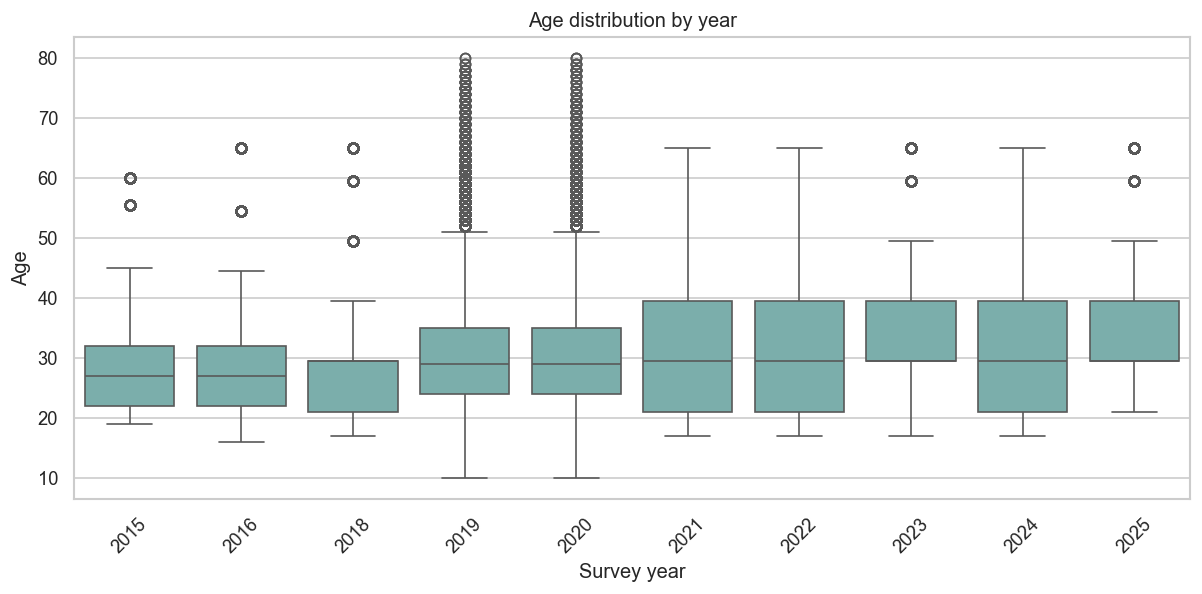

In [60]:
age_summary = core.groupby('survey_year').agg(
    age_coverage=('age_num', lambda s: s.notna().mean()),
    age_median=('age_num', 'median')
)
display(age_summary.round(2))

age_plot = core.loc[core['age_num'].between(10, 80), ['survey_year', 'age_num']]
plt.figure(figsize=(12, 5))
sns.boxplot(data=age_plot, x='survey_year', y='age_num', color='#72B7B2')
plt.title("Age distribution by year")
plt.xlabel('Survey year')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()

**Education, Organization Size, and Remote Trends Across Years**

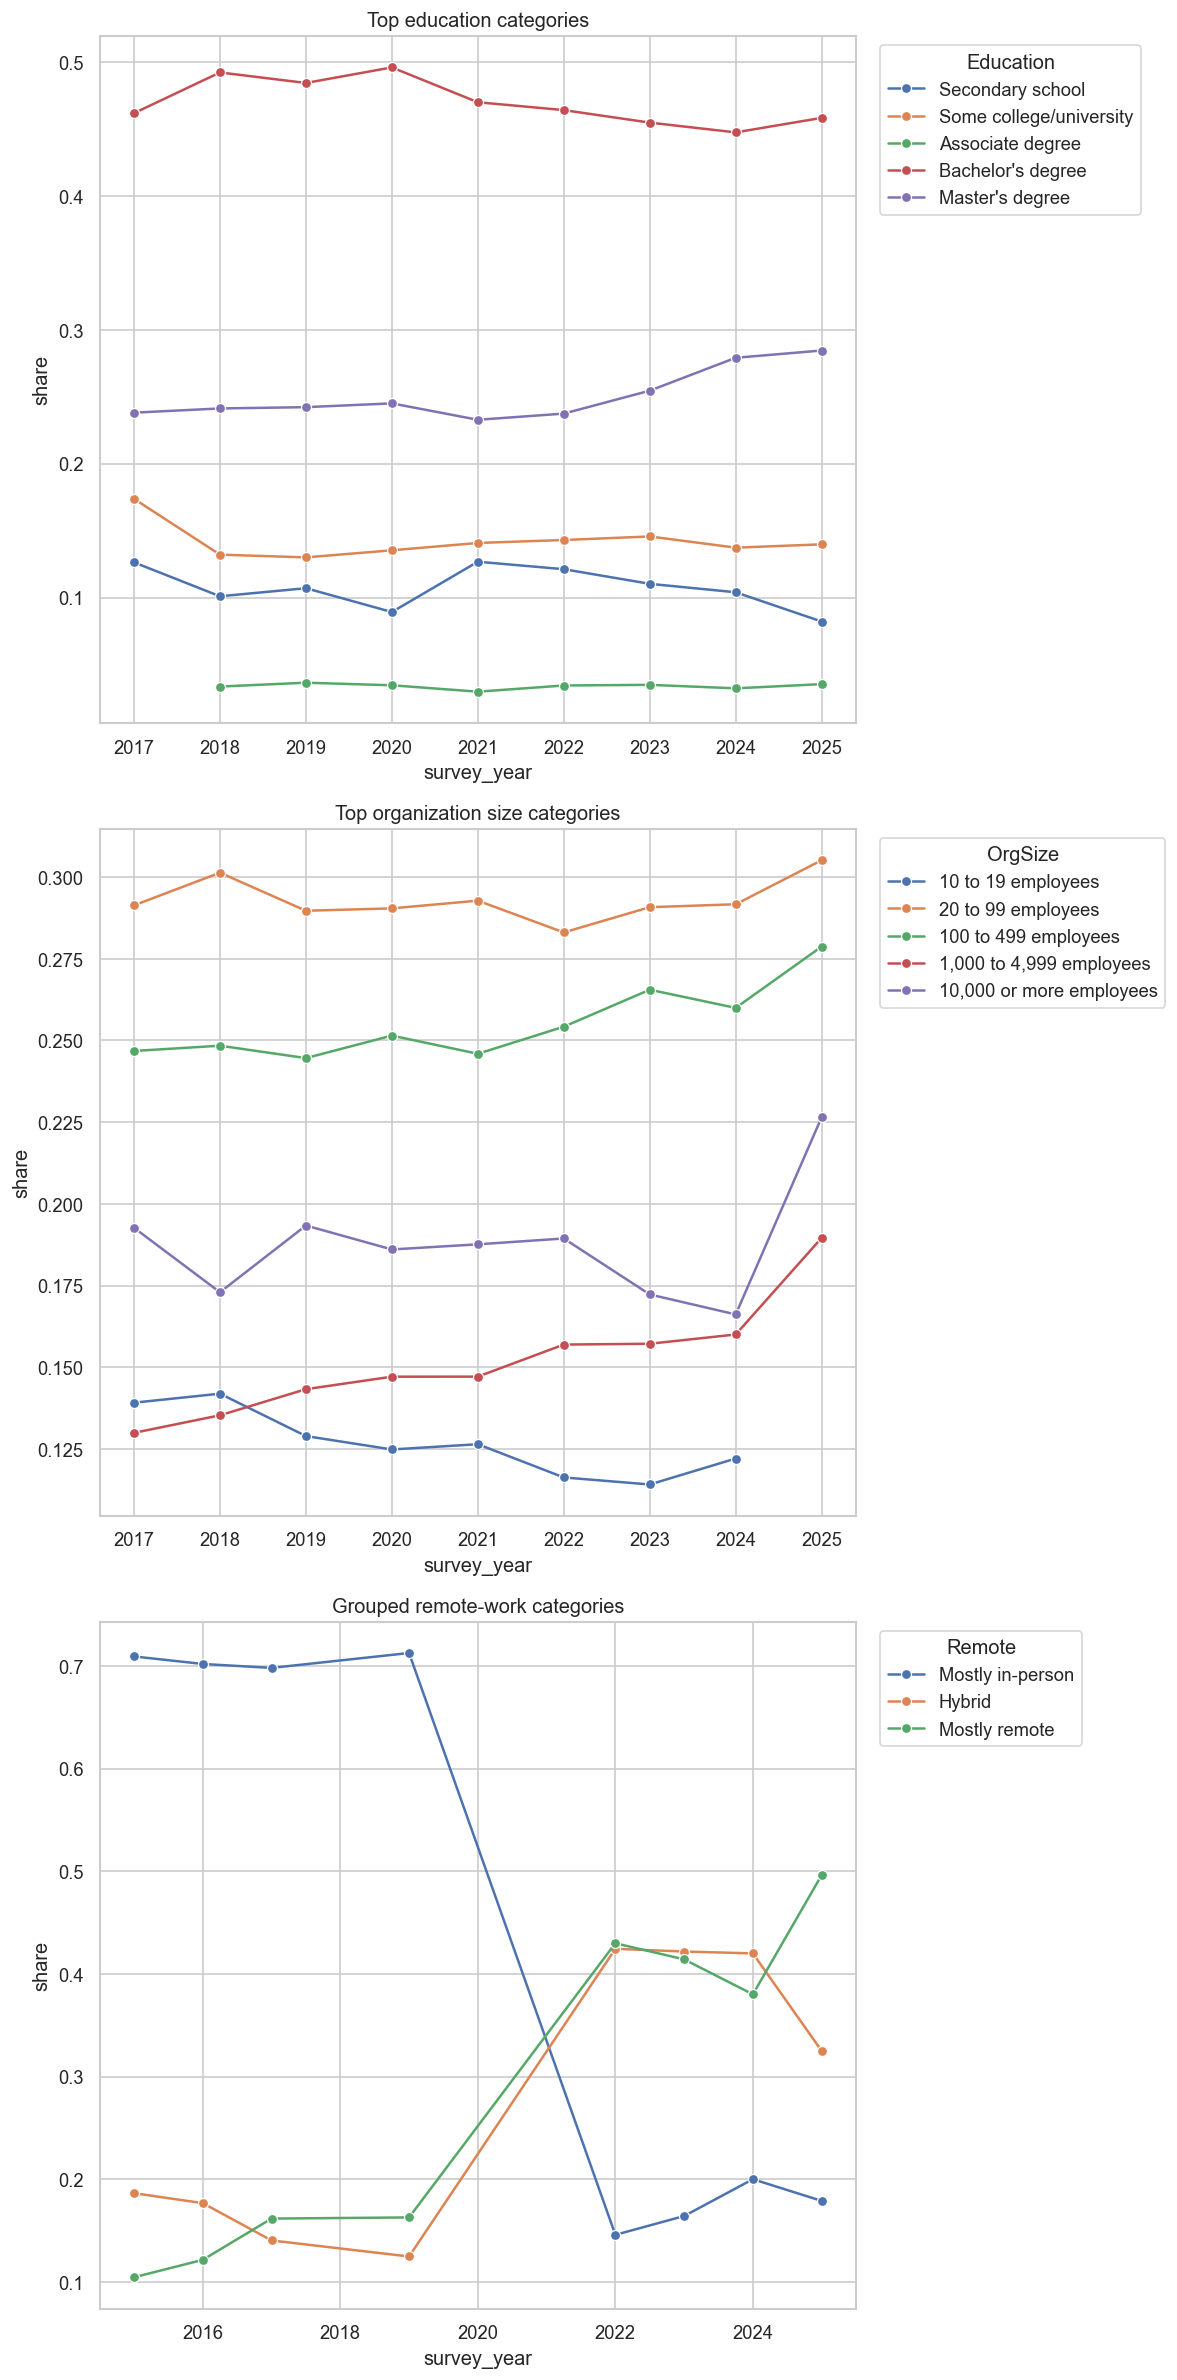

In [61]:
# The three lists below just set the order I want the labels to be shown in
EDUCATION_ORDER = [
    'Primary/elementary school',
    'Secondary school',
    'Some college/university',
    'Associate degree',
    "Bachelor's degree",
    "Master's degree",
    'Professional degree',
    'Doctoral degree'
]

ORG_SIZE_ORDER = [
    'Just me - I am a freelancer, sole proprietor, etc.',
    'I am not part of a company',
    '1-4 employees',
    '2 to 9 employees',
    '2-9 employees',
    '5-9 employees',
    'Fewer than 10 employees',
    '10 to 19 employees',
    '10-19 employees',
    'Less than 20 employees',
    '20 to 99 employees',
    '20-99 employees',
    '100 to 499 employees',
    '100-499 employees',
    '500 to 999 employees',
    '500-999 employees',
    '1,000 to 4,999 employees',
    '1,000-4,999 employees',
    '5,000 to 9,999 employees',
    '5,000-9,999 employees',
    '10,000 or more employees',
    '10,000+ employees',
    "I don't know",
    'I am not sure',
    'I prefer not to answer'
]

REMOTE_GROUP_ORDER = ['Mostly in-person', 'Hybrid', 'Mostly remote']


# Meat of the cell, calculates percent makeup of values per column and orders them as I set
def top_share(frame, column, top_n=5, order=None):
    counts = frame.dropna(subset=[column]).groupby(['survey_year', column]).size().rename('count').reset_index()
    if top_n is None:
        top_values = counts[column].drop_duplicates().tolist()
    else:
        top_values = counts.groupby(column)['count'].sum().nlargest(top_n).index.tolist()
    if order is not None:
        rank = {value: i for i, value in enumerate(order)}
        top_values = sorted(top_values, key=lambda value: rank.get(value, len(rank)))
    counts = counts.loc[counts[column].isin(top_values)].copy()
    counts['share'] = counts['count'] / counts.groupby('survey_year')['count'].transform('sum')
    return counts, top_values


# Remote has many values that can be interpretted similarly, this groups the non-nulls in three categories
def group_remote(value):
    if pd.isna(value):
        return pd.NA

    mostly_in_person = {
        "In-person",
        "Full in-person",
        "Never",
        "Less than once per month / Never",
        "I rarely work remote",
        "I rarely work remotely",
        "A few days each month"
    }
    hybrid = {
        "Less than half the time, but at least one day each week",
        "About half the time",
        "Part-time remote",
        "Part-time Remote",
        "Hybrid (some remote, leans heavy to in-person)",
        "Hybrid (some remote, some in-person)",
        "Your choice (very flexible, you can come in when you want or just as needed)"
    }
    mostly_remote = {
        "More than half, but not all, the time",
        "Hybrid (some in-person, leans heavy to flexibility)",
        "Fully remote",
        "Full-time remote",
        "Full-time Remote",
        "All or almost all the time (I'm full-time remote)",
        "Remote"
    }

    if value in mostly_in_person:
        return 'Mostly in-person'
    if value in hybrid:
        return 'Hybrid'
    if value in mostly_remote:
        return 'Mostly remote'
    return pd.NA


# Education has some duplicate levels from spelling convention and some long titles
plot_core = core[['survey_year', 'education', 'org_size', 'remote']].copy()
plot_core['education_plot'] = (
    plot_core['education']
    .astype('string')
    .str.replace(r'Bachelor.?s', "Bachelor's", regex=True)
    .str.replace(r'Master.?s', "Master's", regex=True)
    .str.replace(r'\s*\([^)]*\)', '', regex=True)
    .replace({
        'Some college/university study without earning a degree': 'Some college/university',
        "Some college/university study without earning a bachelor's degree": 'Some college/university',
        'Other doctoral degree': 'Doctoral degree'
    })
)
plot_core['remote_group'] = plot_core['remote'].map(group_remote)


# Get the top shares for the fixed columns
education_share, education_hue_order = top_share(plot_core, 'education_plot', top_n=5, order=EDUCATION_ORDER)
org_share, org_hue_order = top_share(plot_core, 'org_size', top_n=5, order=ORG_SIZE_ORDER)
remote_share, remote_hue_order = top_share(plot_core, 'remote_group', top_n=None, order=REMOTE_GROUP_ORDER)


# Line plots for each existing values to show trends
fig, axes = plt.subplots(3, 1, figsize=(10, 20))

sns.lineplot(data=education_share, x='survey_year', y='share', hue='education_plot', hue_order=education_hue_order, marker='o', ax=axes[0])
axes[0].set_title("Top education categories")
axes[0].legend(title='Education', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.lineplot(data=org_share, x='survey_year', y='share', hue='org_size', hue_order=org_hue_order, marker='o', ax=axes[1])
axes[1].set_title("Top organization size categories")
axes[1].legend(title='OrgSize', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.lineplot(data=remote_share, x='survey_year', y='share', hue='remote_group', hue_order=remote_hue_order, marker='o', ax=axes[2])
axes[2].set_title("Grouped remote-work categories")
axes[2].legend(title='Remote', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


**Groups Countries into Continents/Regions**
<br>
This one is a bit of a mess and I use a package later to make it easier. You can ignore the code here.

Top unmapped or special country values


country
Venezuela, Bolivarian Republic of...     726
Nomadic                                  255
Other Country (Not Listed Above)         220
I prefer not to say                      140
Côte d'Ivoire                            125
Isle of Man                               61
Other (please specify)                    29
Suriname                                  26
Liechtenstein                             25
Brunei Darussalam                         23
Aland Islands                             22
Monaco                                    20
Trinidad & Tobago                         16
San Marino                                15
Saint Lucia                               14
Democratic People's Republic of Korea     13
Antarctica                                12
Antigua & Deps                            11
Timor-Leste                               11
Papua New Guinea                          10
Name: count, dtype: int64

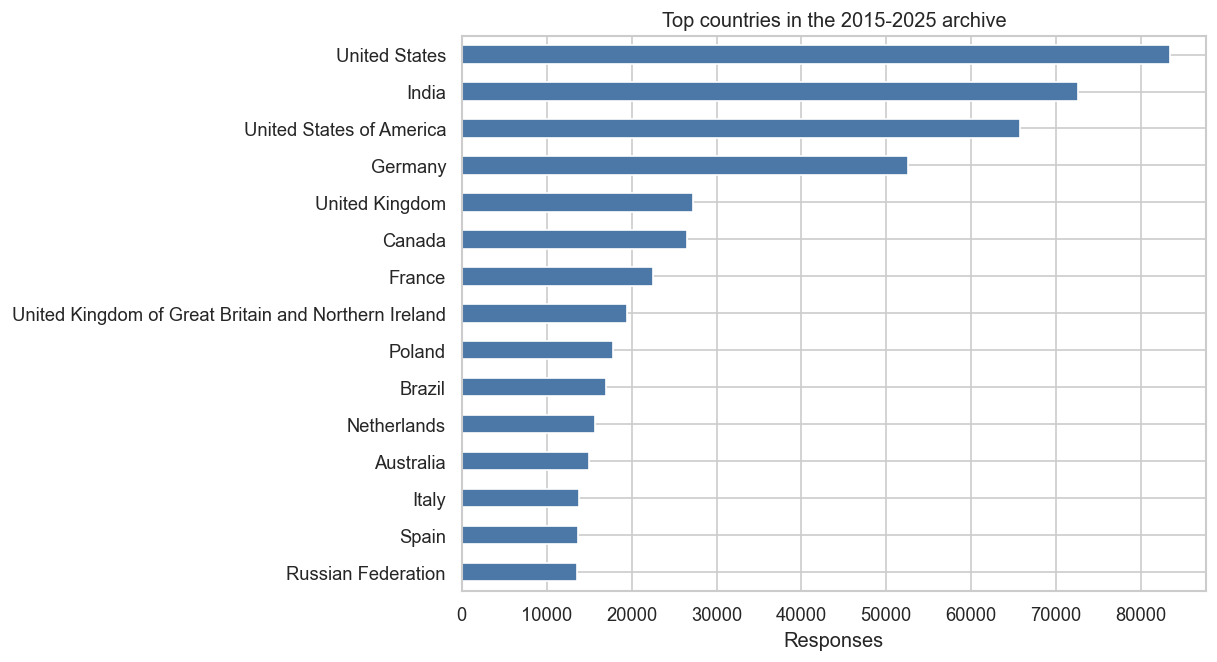

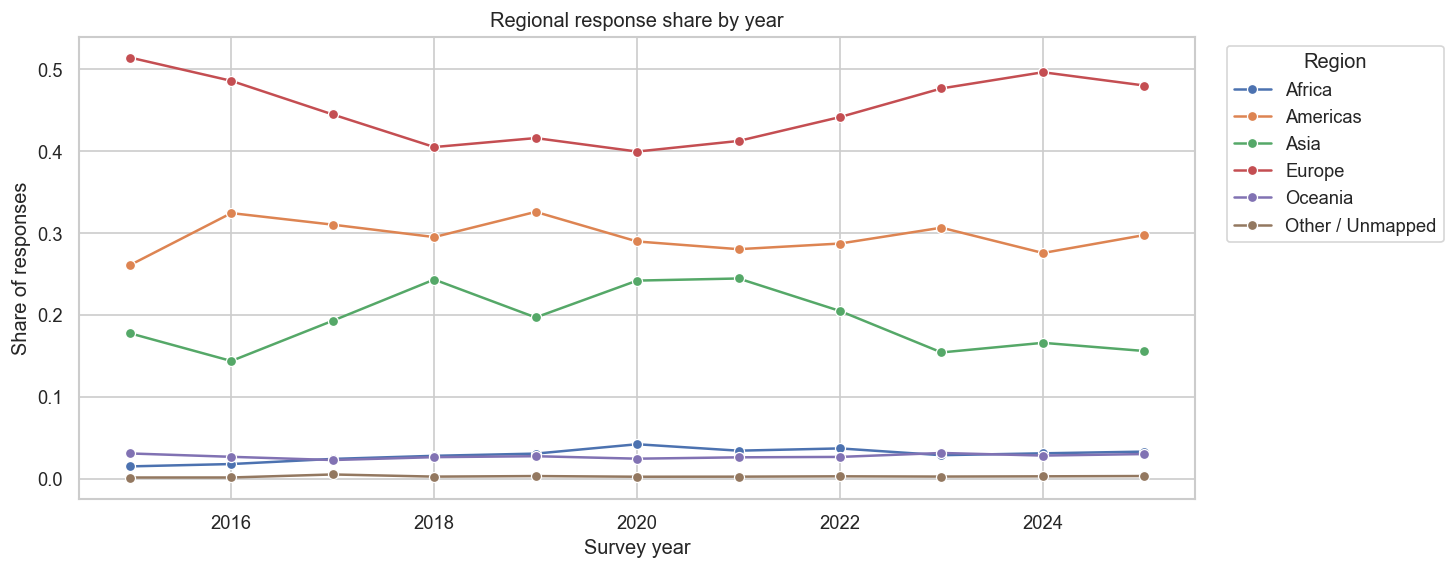

In [62]:
base_region_map = px.data.gapminder()[['country', 'continent']].drop_duplicates()
base_region_map = dict(zip(base_region_map['country'], base_region_map['continent']))

extra_region_map = {
    'United States of America': 'Americas',
    'United Kingdom of Great Britain and Northern Ireland': 'Europe',
    'Russian Federation': 'Europe',
    'Ukraine': 'Europe',
    'Slovakia': 'Europe',
    'Lithuania': 'Europe',
    'Belarus': 'Europe',
    'Estonia': 'Europe',
    'Latvia': 'Europe',
    'Ireland {Republic}': 'Europe',
    'Republic of Moldova': 'Europe',
    'Moldova': 'Europe',
    'Moldavia': 'Europe',
    'Luxembourg': 'Europe',
    'Malta': 'Europe',
    'Kosovo': 'Europe',
    'The former Yugoslav Republic of Macedonia': 'Europe',
    'Republic of North Macedonia': 'Europe',
    'Macedonia': 'Europe',
    'Bosnia Herzegovina': 'Europe',
    'Bosnia-Herzegovina': 'Europe',
    'Andorra': 'Europe',
    'Cyprus': 'Europe',
    'Georgia': 'Europe',
    'United Arab Emirates': 'Asia',
    'Republic of Korea': 'Asia',
    'Korea South': 'Asia',
    'South Korea': 'Asia',
    'Hong Kong': 'Asia',
    'Hong Kong (S.A.R.)': 'Asia',
    'Kazakhstan': 'Asia',
    'Armenia': 'Asia',
    'Azerbaijan': 'Asia',
    'Uzbekistan': 'Asia',
    'Kyrgyzstan': 'Asia',
    'Qatar': 'Asia',
    'Yemen': 'Asia',
    'Tajikistan': 'Asia',
    'Bhutan': 'Asia',
    'Maldives': 'Asia',
    'Turkmenistan': 'Asia',
    'Fiji': 'Oceania',
    'Barbados': 'Americas',
    'Guyana': 'Americas',
    'Bahamas': 'Americas',
    'Antigua and Barbuda': 'Americas',
    'Belize': 'Americas',
    "C?te d'Ivoire": 'Africa',
    "C??te d'Ivoire": 'Africa',
    'Libyan Arab Jamahiriya': 'Africa',
    'Iran, Islamic Republic of...': 'Asia',
    'Viet Nam': 'Asia',
    'Syrian Arab Republic': 'Asia',
    'United Republic of Tanzania': 'Africa',
    'Palestine': 'Asia',
    'Congo, Republic of the...': 'Africa',
    'Democratic Republic of the Congo': 'Africa',
    'North Korea': 'Asia',
    'Myanmar, {Burma}': 'Asia',
    "Lao People's Democratic Republic": 'Asia',
    'Cape Verde': 'Africa',
    'Azerbaidjan': 'Asia',
    'Nomadic': 'Other / Unmapped',
    'Other Country (Not Listed Above)': 'Other / Unmapped',
    'I prefer not to say': 'Other / Unmapped'
}


# Assign region to given country
def map_region(country):
    if pd.isna(country):
        return np.nan
    country = str(country).strip()
    if country in extra_region_map:
        return extra_region_map[country]
    return base_region_map.get(country, 'Other / Unmapped')


core['region'] = core['country'].map(map_region)

unmapped = core.loc[core['region'].eq('Other / Unmapped'), 'country'].value_counts().head(20)
print("Top unmapped or special country values")
display(unmapped)

top_countries = core['country'].dropna().value_counts().head(15).sort_values()
plt.figure(figsize=(8, 6))
top_countries.plot(kind='barh', color='#4C78A8')
plt.title("Top countries in the 2015-2025 archive")
plt.xlabel("Responses")
plt.ylabel('')
plt.show()

region_counts = core.groupby(['survey_year', 'region']).size().rename('count').reset_index()
region_counts['share'] = region_counts['count'] / region_counts.groupby('survey_year')['count'].transform('sum')

plt.figure(figsize=(12, 5))
sns.lineplot(data=region_counts, x='survey_year', y='share', hue='region', marker='o')
plt.title("Regional response share by year")
plt.xlabel("Survey year")
plt.ylabel("Share of responses")
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


## Experience And Role Structure

These sections are useful for both modeling experience and role create a lot of the differences in compensation, satisfaction, and technology choice.


,years_code_coverage,years_code_median,years_code_pro_coverage,years_code_pro_median,work_exp_coverage,work_exp_median
survey_year,,,,,,
2015,0.95,3.5,0.00,NaN,0.00,NaN
2016,0.88,3.5,0.88,3.5,0.00,NaN
2017,0.97,9.5,0.74,5.5,0.00,NaN
2018,0.95,7.0,0.79,4.0,0.00,NaN
2019,0.99,9.0,0.84,6.0,0.00,NaN
2020,0.89,10.0,0.72,6.0,0.00,NaN
2021,0.98,10.0,0.73,6.0,0.00,NaN
2022,0.97,9.0,0.71,7.0,0.50,8.0
2023,0.98,11.0,0.74,9.0,0.49,9.0


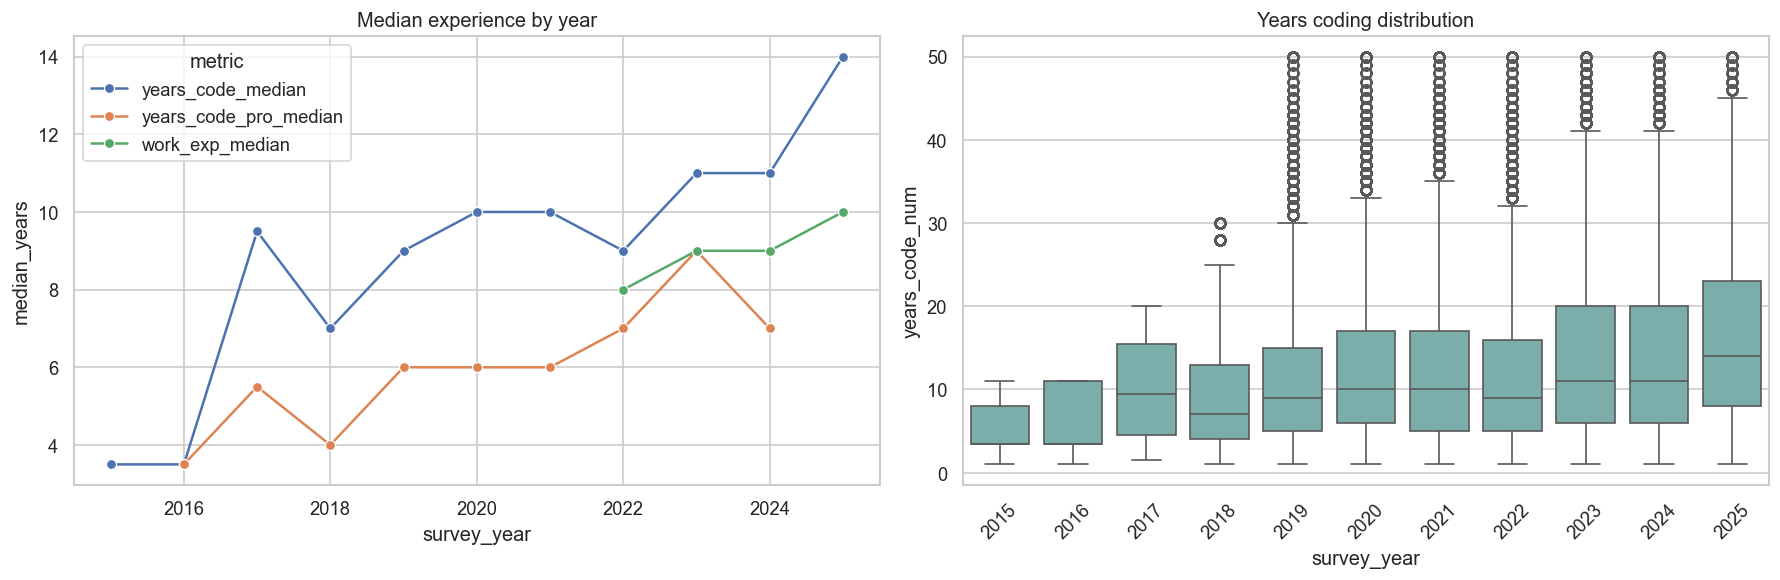

In [63]:
# Median values for each of the experience columns
exp_summary = core.groupby('survey_year').agg(
    years_code_coverage=('years_code_num', lambda s: s.notna().mean()),
    years_code_median=('years_code_num', 'median'),
    years_code_pro_coverage=('years_code_pro_num', lambda s: s.notna().mean()),
    years_code_pro_median=('years_code_pro_num', 'median'),
    work_exp_coverage=('work_exp_num', lambda s: s.notna().mean()),
    work_exp_median=('work_exp_num', 'median')
)
display(exp_summary.round(2))


# Long format = good for plot
exp_long = exp_summary.reset_index().melt(
    id_vars='survey_year',
    value_vars=['years_code_median', 'years_code_pro_median', 'work_exp_median'],
    var_name='metric',
    value_name='median_years'
)


# Median experience trend where present and box plots for general years coding by year
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=exp_long, x='survey_year', y='median_years', hue='metric', marker='o', ax=axes[0])
axes[0].set_title("Median experience by year")

exp_box = core.loc[core['years_code_num'].between(0, 50), ['survey_year', 'years_code_num']]
sns.boxplot(data=exp_box, x='survey_year', y='years_code_num', color='#72B7B2', ax=axes[1])
axes[1].set_title("Years coding distribution")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


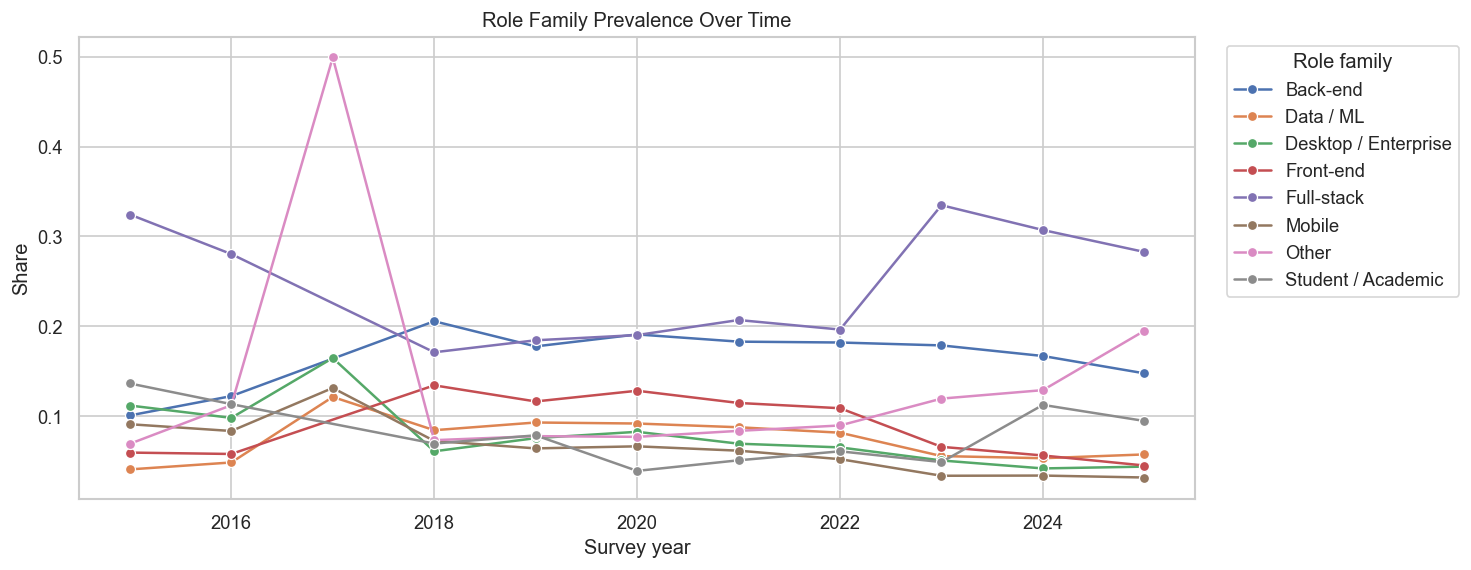

In [64]:
# Creates potential role groups for the various responses across the dataset
def role_family(token):
    if pd.isna(token):
        return np.nan
    t = str(token).strip().lower()
    if 'full-stack' in t:
        return 'Full-stack'
    if 'back-end' in t or 'backend' in t or 'server' in t:
        return 'Back-end'
    if 'front-end' in t or 'frontend' in t:
        return 'Front-end'
    if 'data' in t or 'machine learning' in t or 'scientist' in t or 'analyst' in t:
        return 'Data / ML'
    if 'mobile' in t or 'ios' in t or 'android' in t:
        return 'Mobile'
    if 'devops' in t or 'site reliability' in t or 'cloud' in t or 'system administrator' in t:
        return 'DevOps / Cloud'
    if 'desktop' in t or 'enterprise' in t:
        return 'Desktop / Enterprise'
    if 'manager' in t or 'executive' in t:
        return 'Management'
    if 'student' in t or 'academic researcher' in t or 'educator' in t:
        return 'Student / Academic'
    if 'qa' in t or 'quality assurance' in t or 'test' in t:
        return 'QA / Testing'
    return 'Other'

# The roles are often multiselect columns with values separated by semicolons, this handles that
roles = core.loc[core['dev_type'].notna(), ['row_id', 'survey_year', 'dev_type']].copy()
roles['dev_type'] = roles['dev_type'].astype(str).str.split(';')
roles = roles.explode('dev_type')
roles['dev_type'] = roles['dev_type'].str.strip()
roles['role_family'] = roles['dev_type'].map(role_family)

# Counts the percent share each role makes per year and avoids duplicate responses
role_prev = roles.groupby(['survey_year', 'role_family'])['row_id'].nunique().rename('respondents').reset_index()
role_prev['share'] = role_prev['respondents'] / role_prev.groupby('survey_year')['respondents'].transform('sum')

top_role_families = role_prev.groupby('role_family')['respondents'].sum().nlargest(8).index
role_prev = role_prev.loc[role_prev['role_family'].isin(top_role_families)]


# Plot of how roles have changed over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=role_prev, x='survey_year', y='share', hue='role_family', marker='o')
plt.title("Role Family Prevalence Over Time")
plt.xlabel("Survey year")
plt.ylabel("Share")
plt.legend(title='Role family', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

## Compensation Baseline

Compensation is the main project question I'm trying to answer, so the baseline should already show:
- coverage by year
- broad trend direction
- subgroup differences by region, role family, education, and remote-work status

The more recent years (particularly 2019+) have stronger compensation data, but I'll work with as many years as I can.

,coverage,median_comp
survey_year,,
2015,0.6,50000.0
2016,0.7,45000.0
2017,0.3,50000.0
2018,0.5,55075.0
2019,0.6,57287.0
2020,0.5,54049.0
2021,0.6,56211.0
2022,0.5,67845.0
2023,0.5,74963.0


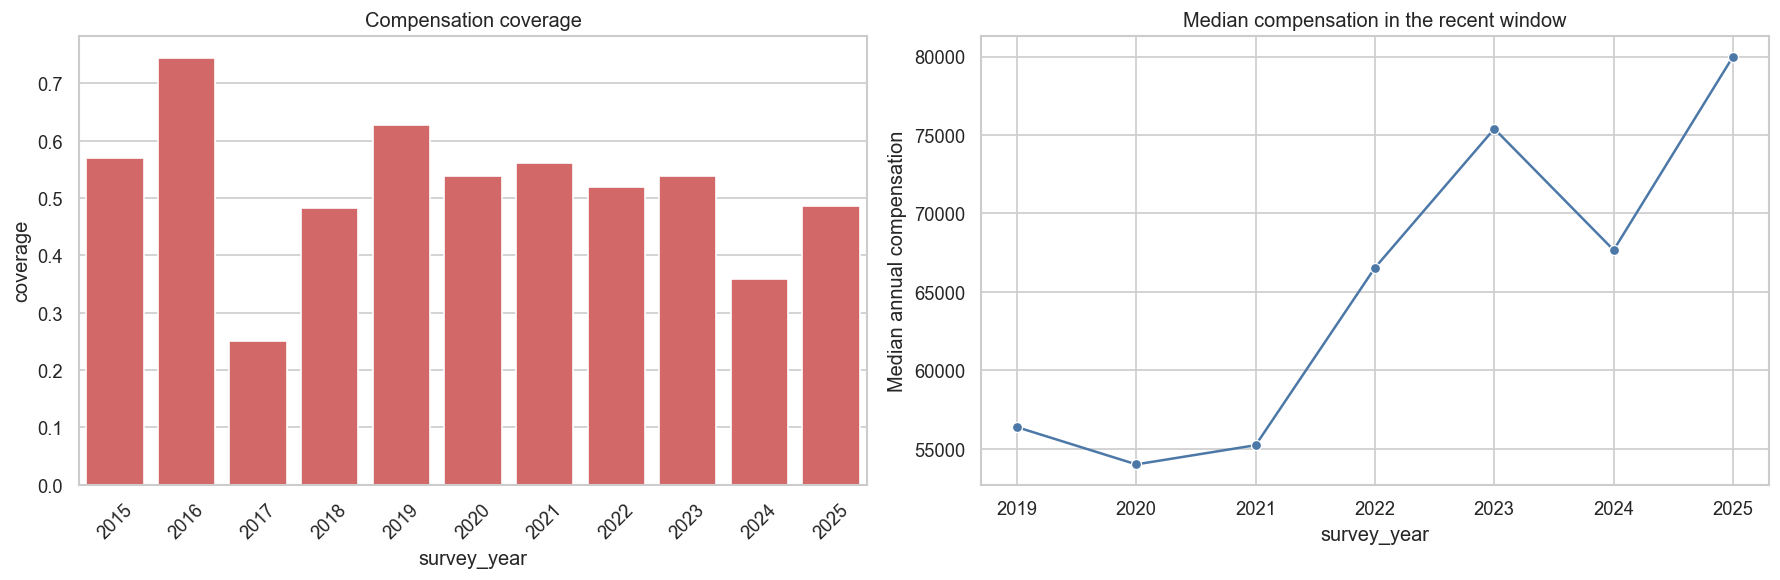

,survey_year,region,n,median_comp
0,2019,Africa,1111,13572.0
1,2019,Americas,17266,90000.0
2,2019,Asia,7271,14256.0
3,2019,Europe,21784,49059.0
4,2019,Oceania,1427,76156.0
6,2020,Africa,782,14142.0
7,2020,Americas,10262,90000.0
8,2020,Asia,4960,13616.5
9,2020,Europe,13979,49704.0
10,2020,Oceania,873,73491.0


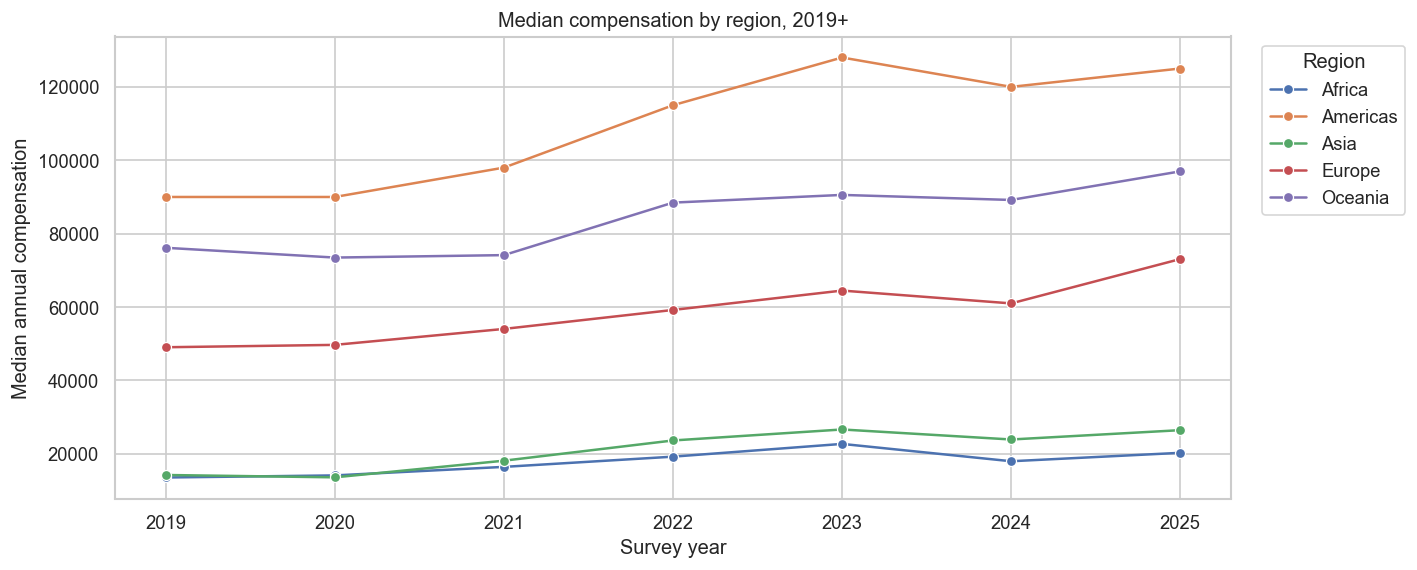

In [65]:
# Gets what percent of responses gave their salary and what the mean was
comp_summary = core.groupby('survey_year').agg(
    coverage=('comp_usd', lambda s: s.notna().mean()),
    median_comp=('comp_usd', 'median')
)
display(comp_summary.round(1))

# Looks at only 2019+ and those marked as being compensated, grouped by years of experience
comp_recent = core.loc[core['survey_year'] >= 2019].copy()
comp_recent = comp_recent.loc[comp_recent['is_comp_sample']].copy()
comp_recent['exp_bin'] = pd.cut(
    comp_recent['years_code_pro_num'],
    bins=[0, 2, 5, 10, 20, 40],
    labels=['0-2', '3-5', '6-10', '11-20', '21+'],
    include_lowest=True
)


# Bar plot of summary amount (coverage and median)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=comp_summary.reset_index(), x='survey_year', y='coverage', color='#E45756', ax=axes[0])
axes[0].set_title("Compensation coverage")
axes[0].tick_params(axis='x', rotation=45)

recent_year_median = comp_recent.groupby('survey_year')['comp_usd'].median().reset_index()
sns.lineplot(data=recent_year_median, x='survey_year', y='comp_usd', marker='o', color='#4C78A8', ax=axes[1])
axes[1].set_title("Median compensation in the recent window")
axes[1].set_ylabel("Median annual compensation")

plt.tight_layout()
plt.show()


# Groups compensation by assigned region to get median by category
region_comp = comp_recent.groupby(['survey_year', 'region']).agg(n=('row_id', 'nunique'), median_comp=('comp_usd', 'median')).reset_index()
region_comp = region_comp.loc[region_comp['n'] >= 300]
display(region_comp)

plt.figure(figsize=(12, 5))
sns.lineplot(data=region_comp, x='survey_year', y='median_comp', hue='region', marker='o')
plt.title("Median compensation by region, 2019+")
plt.ylabel("Median annual compensation")
plt.xlabel("Survey year")
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


,role_family,n,median_comp
6,Management,19860,85788.0
3,DevOps / Cloud,32916,70380.0
8,Other,39190,63808.0
1,Data / ML,36195,62500.0
5,Full-stack,120178,61071.0
0,Back-end,100252,60696.0
2,Desktop / Enterprise,36426,60000.0
9,QA / Testing,11077,57573.0
4,Front-end,56386,52186.0
7,Mobile,28829,47563.0


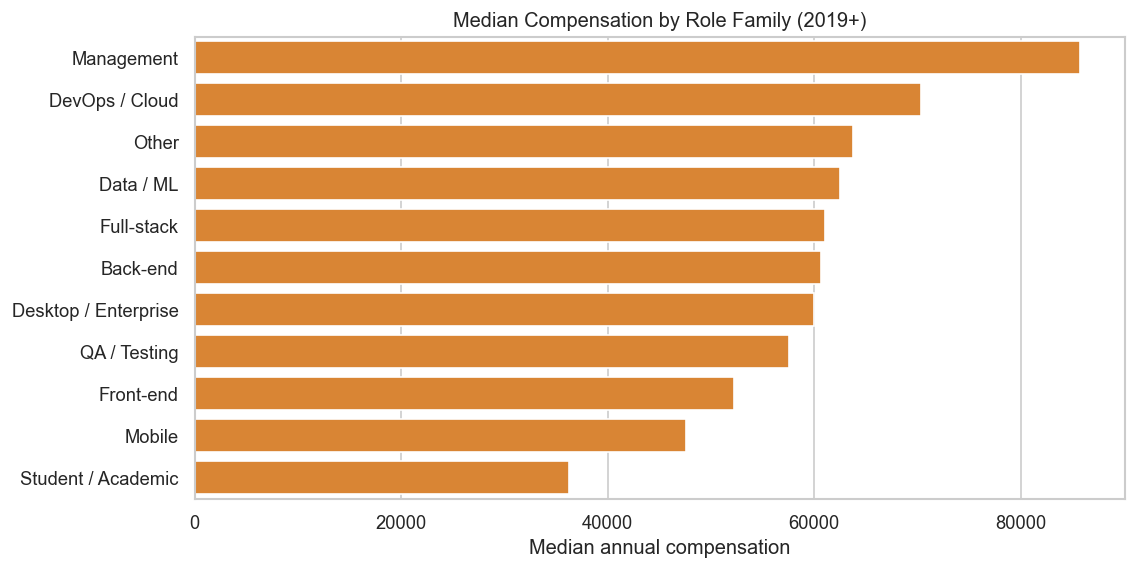

,education,n,median_comp
11,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",3394,85925.0
9,"Other doctoral degree (Ph.D., Ed.D., etc.)",2759,81666.0
5,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",50852,69608.0
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",92362,66538.0
1,"Associate degree (A.A., A.S., etc.)",6248,64088.0
14,Some college/university study without earning ...,28649,59000.0
3,"Bachelor’s degree (BA, BS, B.Eng., etc.)",24294,58881.0
6,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",11888,57969.5
13,"Secondary school (e.g. American high school, G...",11297,47180.0
12,"Professional degree (JD, MD, etc.)",2313,36000.0


,remote,n,median_comp
13,Remote,35031,85967.0
5,"Hybrid (some in-person, leans heavy to flexibi...",3387,81210.0
14,"Your choice (very flexible, you can come in wh...",2355,78890.0
4,Fully remote,15869,78084.0
6,"Hybrid (some remote, leans heavy to in-person)",3619,75410.0
10,"Less than half the time, but at least one day ...",4557,74474.0
2,All or almost all the time (I'm full-time remote),5789,70200.0
7,"Hybrid (some remote, some in-person)",41332,69372.0
0,A few days each month,12396,65308.0
12,"More than half, but not all, the time",1500,58840.5


In [66]:
# Inner join to just get records where the columns exist
role_comp = roles.merge(
    comp_recent[['row_id', 'comp_usd', 'education', 'remote', 'region']],
    on='row_id',
    how='inner'
)


# Groups responses by their assigned role family and gets the median compensation
role_comp_summary = role_comp.groupby('role_family').agg(
    n=('row_id', 'nunique'),
    median_comp=('comp_usd', 'median')
).reset_index()
role_comp_summary = role_comp_summary.loc[role_comp_summary['n'] >= 2000].sort_values('median_comp', ascending=False)
display(role_comp_summary)


# Plot to visually see role compensation
plt.figure(figsize=(10, 5))
sns.barplot(data=role_comp_summary, x='median_comp', y='role_family', color='#F58518')
plt.title("Median Compensation by Role Family (2019+)")
plt.xlabel("Median annual compensation")
plt.ylabel('')
plt.show()


# Compensation by education (I didn't use the fixed values here)
edu_comp = comp_recent.groupby('education').agg(n=('row_id', 'nunique'), median_comp=('comp_usd', 'median')).reset_index()
edu_comp = edu_comp.loc[edu_comp['n'] >= 2000].sort_values('median_comp', ascending=False)
display(edu_comp.head(10))


# Compensation by remote status (again, too lazy to pull the grouped categories)
remote_comp = comp_recent.groupby('remote').agg(n=('row_id', 'nunique'), median_comp=('comp_usd', 'median')).reset_index()
remote_comp = remote_comp.loc[remote_comp['n'] >= 500].sort_values('median_comp', ascending=False)
display(remote_comp)

## Satisfaction Baseline

I'm not looking too much into satisfaction, but I can at least use the notebook to:
- which years have usable satisfaction fields
- what the raw response structure looks like
- how recent numeric satisfaction behaves across subgroups

,job_sat_coverage,career_sat_coverage,numeric_job_sat
survey_year,,,
2015,0.62,0.00,0.00
2016,0.00,0.00,0.00
2017,0.79,0.83,0.79
2018,0.70,0.77,0.00
2019,0.80,0.82,0.00
2020,0.70,0.00,0.00
2021,0.00,0.00,0.00
2022,0.00,0.00,0.00
2023,0.00,0.00,0.00


,survey_year,job_sat,count
0,2015,I'm somewhat satisfied with my job,6540
1,2015,I love my job,5819
2,2015,I'm neither satisfied nor dissatisfied with my...,1775
3,2015,I'm somewhat dissatisfied with my job,1565
4,2015,I hate my job,305
5,2017,8.0,8983
6,2017,7.0,7969
7,2017,9.0,5573
8,2017,6.0,4726
9,2017,10.0,4148


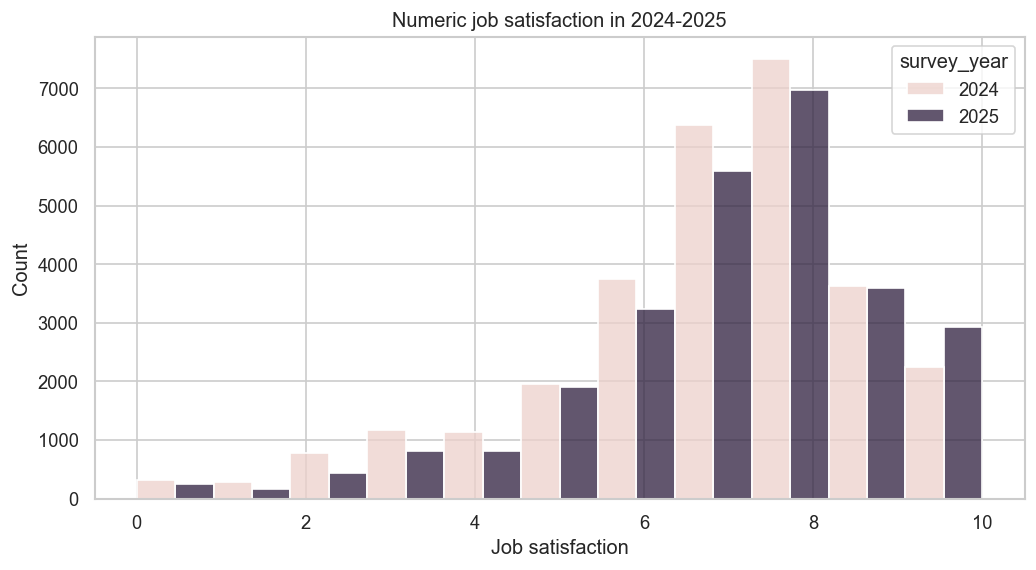

In [67]:
# Get the percent of responses that non-null include job satisfaction responses
sat_summary = core.groupby('survey_year').agg(
    job_sat_coverage=('job_sat', lambda s: s.notna().mean()),
    career_sat_coverage=('career_sat', lambda s: s.notna().mean()),
    numeric_job_sat=('job_sat_num', lambda s: s.notna().mean())
)
display(sat_summary.round(2))


# Get the top satisfaction responses across the years
top_sat_rows = []
for year, frame in core.groupby('survey_year'):
    top = frame['job_sat'].dropna().astype(str).value_counts().head(5)
    for label, count in top.items():
        top_sat_rows.append({'survey_year': year, 'job_sat': label, 'count': count})

display(pd.DataFrame(top_sat_rows))


# Show the distribution of numeric satisifaction ratings across the two most recent years
sat_recent = core.loc[core['survey_year'].isin([2024, 2025]) & core['job_sat_num'].between(0, 10)].copy()
plt.figure(figsize=(10, 5))
sns.histplot(data=sat_recent, x='job_sat_num', hue='survey_year', multiple='dodge', bins=11)
plt.title("Numeric job satisfaction in 2024-2025")
plt.xlabel("Job satisfaction")
plt.show()

In [68]:
# Inner join to keep records that have satisfaction and columns to group it by
sat_role = roles.merge(
    core[['row_id', 'survey_year', 'region', 'remote', 'job_sat_num']],
    on=['row_id', 'survey_year'],
    how='inner'
)
sat_role = sat_role.loc[sat_role['job_sat_num'].between(0, 10) & sat_role['survey_year'].isin([2024, 2025])]

# Median satisfaction rating by region
sat_region = sat_role.groupby('region').agg(n=('row_id', 'nunique'), median_job_sat=('job_sat_num', 'median')).reset_index()
sat_region = sat_region.loc[sat_region['n'] >= 300].sort_values('median_job_sat', ascending=False)
display(sat_region)

# Median satisfaction rating by remote status
sat_remote = sat_role.groupby('remote').agg(n=('row_id', 'nunique'), median_job_sat=('job_sat_num', 'median')).reset_index()
sat_remote = sat_remote.loc[sat_remote['n'] >= 300].sort_values('median_job_sat', ascending=False)
display(sat_remote)

# Median satisfaction rating by assigned role family
sat_role_summary = sat_role.groupby('role_family').agg(n=('row_id', 'nunique'), median_job_sat=('job_sat_num', 'median')).reset_index()
sat_role_summary = sat_role_summary.loc[sat_role_summary['n'] >= 800].sort_values('median_job_sat', ascending=False)
display(sat_role_summary)


,region,n,median_job_sat
1,Americas,15878,8.0
0,Africa,1432,7.0
2,Asia,8402,7.0
3,Europe,27550,7.0
4,Oceania,1532,7.0


,remote,n,median_job_sat
0,"Hybrid (some in-person, leans heavy to flexibi...",4046,8.0
4,Remote,18999,8.0
5,"Your choice (very flexible, you can come in wh...",2848,8.0
1,"Hybrid (some remote, leans heavy to in-person)",4499,7.0
2,"Hybrid (some remote, some in-person)",12602,7.0
3,In-person,8879,7.0


,role_family,n,median_job_sat
6,Management,2585,8.0
8,Other,8116,8.0
0,Back-end,10749,7.0
1,Data / ML,2710,7.0
2,Desktop / Enterprise,2799,7.0
3,DevOps / Cloud,2205,7.0
4,Front-end,3117,7.0
5,Full-stack,19571,7.0
7,Mobile,2117,7.0
10,Student / Academic,1358,7.0


## Technology Baseline

These heatmaps use the share of respondents with a non-null multi-select field who mention each item.

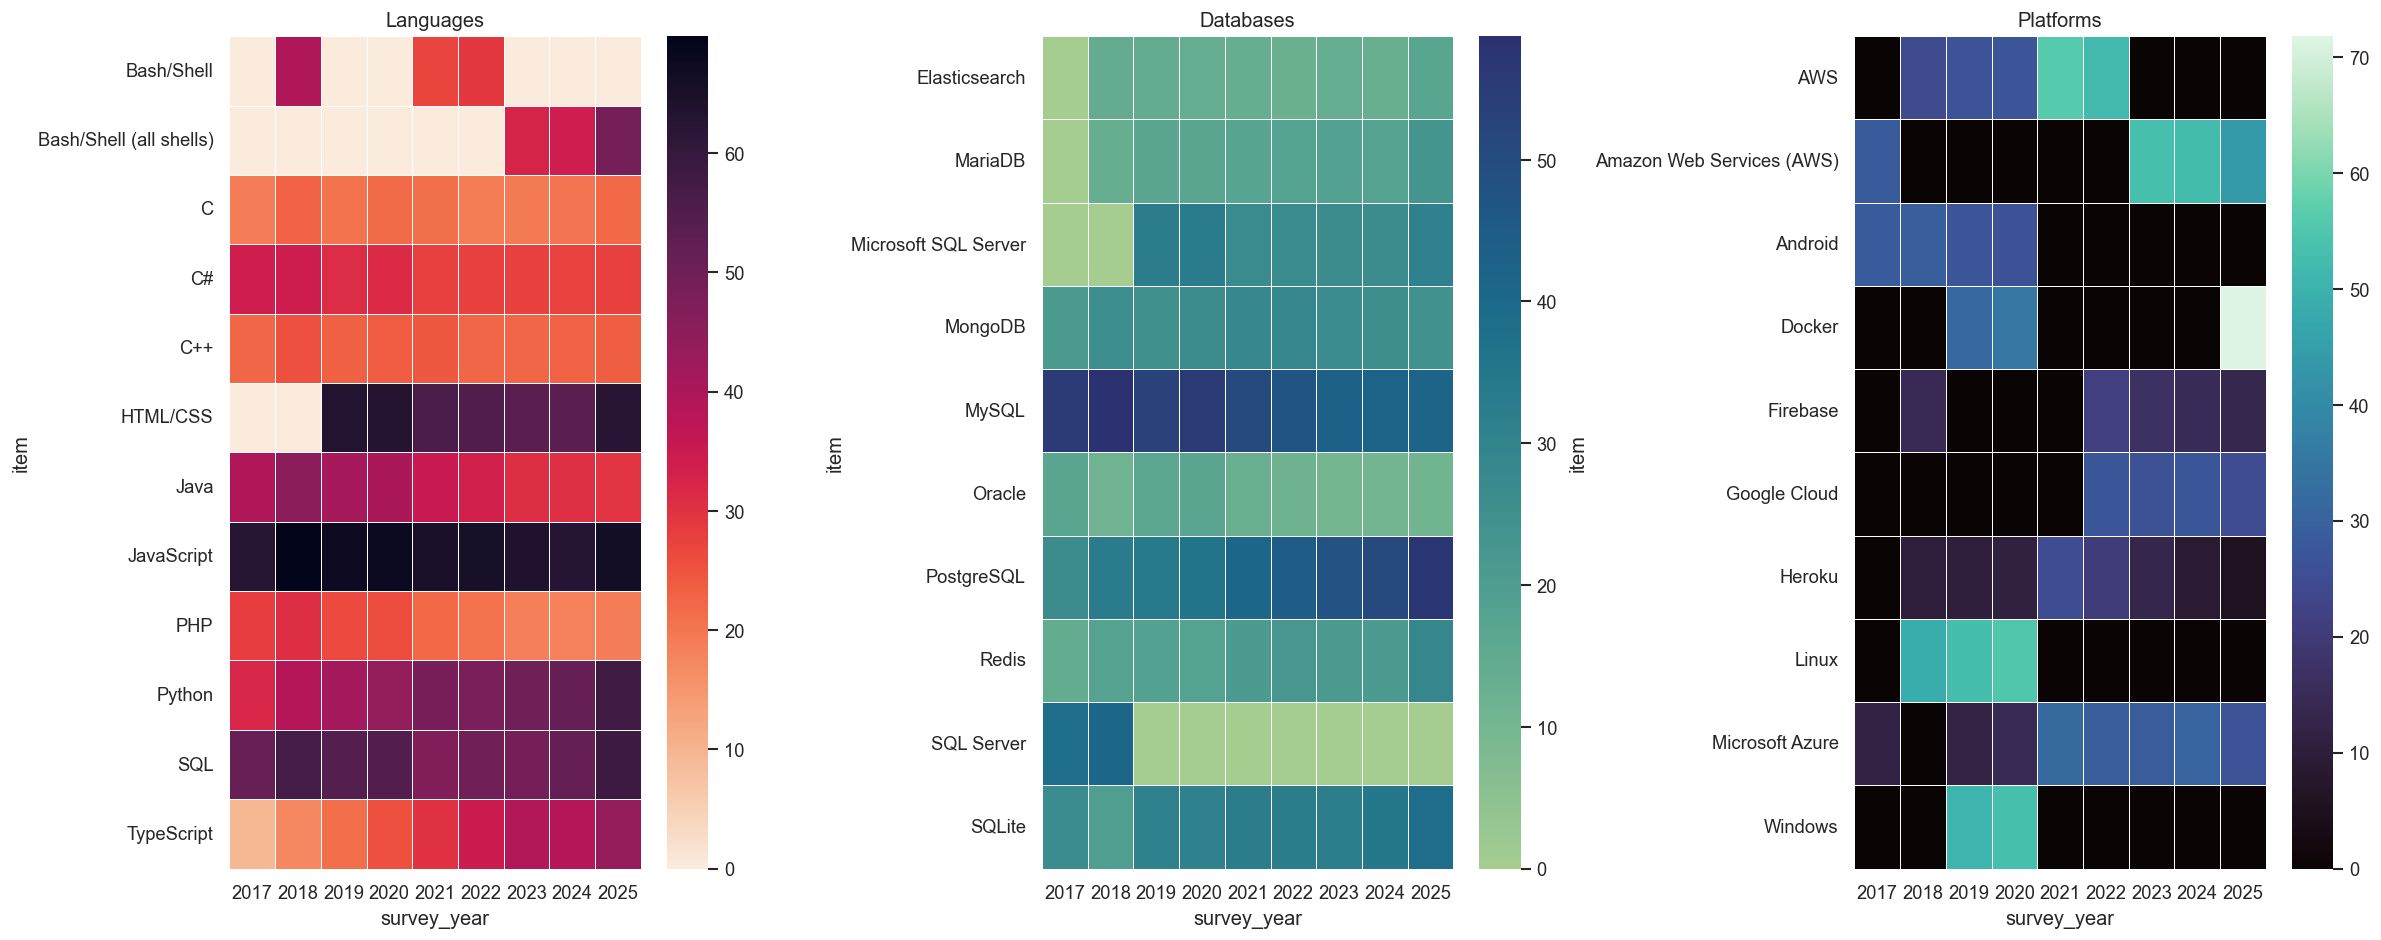

In [69]:
# Gets the prevalance of each values per year for the given tech column
def tech_prevalence(field, min_year=2017, top_n=10):
    rows = []
    for year in YEARS:
        if year < min_year:
            continue
        column = YEAR_INFO[year][field]
        if column is None:
            continue

        data = read_year(year, [column]).rename(columns={column: 'value'})
        denom = data['value'].notna().sum()
        if denom == 0:
            continue

        exploded = data['value'].dropna().astype(str).str.split(';').explode().str.strip()
        exploded = exploded.loc[exploded.ne('')]
        counts = exploded.value_counts()

        for item, count in counts.items():
            rows.append({'survey_year': year, 'item': item, 'count': count, 'share': count / denom})

    out = pd.DataFrame(rows)
    top_items = out.groupby('item')['count'].sum().nlargest(top_n).index
    out = out.loc[out['item'].isin(top_items)].copy()
    return out


language_prev = tech_prevalence('language', min_year=2017, top_n=12)
database_prev = tech_prevalence('database', min_year=2017, top_n=10)
platform_prev = tech_prevalence('platform', min_year=2017, top_n=10)


# Heatmaps showing the percent share of responses that included each of the values per year
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

sns.heatmap(language_prev.pivot(index='survey_year', columns='item', values='share').fillna(0).T * 100, cmap='rocket_r', linewidths=0.5, ax=axes[0])
axes[0].set_title("Languages")

sns.heatmap(database_prev.pivot(index='survey_year', columns='item', values='share').fillna(0).T * 100, cmap='crest', linewidths=0.5, ax=axes[1])
axes[1].set_title("Databases")

sns.heatmap(platform_prev.pivot(index='survey_year', columns='item', values='share').fillna(0).T * 100, cmap='mako', linewidths=0.5, ax=axes[2])
axes[2].set_title("Platforms")

plt.tight_layout()
plt.show()

## AI Baseline

Splits the AI views by what is actually comparable:
- AI use categories are mainly in 2024-2025
- AI sentiment runs more cleanly across 2023-2025, but there are some mentions further back with a different format

In [70]:
# Gets the top responses per year for people's use of AI
ai_use_rows = []
for year in [2024, 2025]:
    frame = core.loc[core['survey_year'] == year]
    top = frame['ai_use'].dropna().astype(str).value_counts().head(5)
    for label, count in top.items():
        ai_use_rows.append({'survey_year': year, 'ai_use': label, 'count': count})


# Gets the top responses per year for people's feelings about AI
ai_sent_rows = []
for year in [2023, 2024, 2025]:
    frame = core.loc[core['survey_year'] == year]
    top = frame['ai_sent'].dropna().astype(str).value_counts().head(5)
    for label, count in top.items():
        ai_sent_rows.append({'survey_year': year, 'ai_sent': label, 'count': count})

print("AI use")
display(pd.DataFrame(ai_use_rows))

print("AI sentiment")
display(pd.DataFrame(ai_sent_rows))


AI use


,survey_year,ai_use,count
0,2024,Yes,37662
1,2024,"No, and I don't plan to",14837
2,2024,"No, but I plan to soon",8408
3,2025,"Yes, I use AI tools daily",15883
4,2025,"Yes, I use AI tools weekly",5958
5,2025,"No, and I don't plan to",5454
6,2025,"Yes, I use AI tools monthly or infrequently",4628
7,2025,"No, but I plan to soon",1797


AI sentiment


,survey_year,ai_sent,count
0,2023,Favorable,29863
1,2023,Very favorable,17050
2,2023,Indifferent,10147
3,2023,Unsure,2471
4,2023,Unfavorable,1698
5,2024,Favorable,22167
6,2024,Very favorable,10848
7,2024,Indifferent,8564
8,2024,Unfavorable,2381
9,2024,Unsure,1357


## What To Do Next

Highest priority follow-ups:
- lock in a better country to region mapping strategy
- define the professional respondent cohort more formally
- select modeling windows per question rather than trying to force a single one if I go beyond the compensation question
- build a proper compensation cleaning notebook
- move the strongest reusable logic into `.py` files for cleaner reusability

Based on the EDA, potential next tracks are:
- 2019+ compensation modeling (can go further back with my in-depth cleaning)
- 2024-2025 job satisfaction modeling
- 2023-2025 AI usage and sentiment analysis
- regional descriptors and subgroup profiles